# Factor Buckets: S&P 500 Stock Clustering with K-Means

> **Contents**  
> - Preprocessing pipeline code  
> - Cluster validation metrics  
> - Centroid values  
> - Portfolio backtest implementation  

> **Prerequisites**  
> - Familiarity with factor-based investing concepts  
> - Understanding of K-Means clustering  

> **Overview**  
> This end-to-end project walks through harvesting S&P 500 data, engineering factor exposures, applying K-Means to form “style” buckets, validating cluster quality, and testing a simple portfolio strategy based on those buckets.

> **Data**  
> Use the official yfinance API to download historical price and fundamental data.

> **Further Reading**  
> For methodology rationale and business context, see [From Fundamentals to Factor Buckets](https://medium.com/@rmmrinal.q/from-fundamentals-to-factor-buckets-a-clustering-approach-to-stock-styles-for-investors-498c5de72504) on Medium.

> **Status**  
> 🚧 *Work in progress — apologies for any disconnects or incomplete sections.*


In [28]:
# Importing basic data processing libraries 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd 
from etl import data_ingest as pl 
import yfinance as yf
import os

In [29]:
# Setting path to fetch data 
base_dir = os.path.abspath(os.path.join(os.getcwd(),".."))
path = os.path.join(base_dir,'Data', 'Raw_data')

# Data & Pre-processing


#### Below Section will talk about data and exploratatory data analysis 

In [30]:
# Load the files
fundamentals_df = pd.read_csv(f'{path}/fundamental_metrics.csv')
risk_df = pd.read_csv(f'{path}/risk_return_metrics.csv')
sp500_df = pd.read_csv(f'{path}/metadata_us_companies.csv')
# Display first few rows
print("📊 Fundamentals Data Preview:")
display(fundamentals_df.head())

print("\n📊 Risk-Return Data Preview:")
display(risk_df.head())

print("\n📊 S&P 500 List Preview:")
display(sp500_df.head())


📊 Fundamentals Data Preview:


,stock_id,trailing_pe,forward_pe,price_to_book,price_to_sales,peg_ratio,profit_margin,return_on_equity,return_on_assets,revenue_growth,eps_growth,dividend_yield,debt_to_equity,current_ratio,market_cap,operating_cash_flow,free_cash_flow,created_at
0,910000,18.687326,17.173418,19.049423,3.074677,NaN,0.16981,0.91851,0.05929,0.001,-0.230,0.028630,350.770,1.411,7.556018e+10,1.819000e+09,1.678875e+09,2025-04-22
1,910001,17.365013,15.487715,4.829898,2.424506,NaN,0.13976,0.28627,0.13533,-0.077,-0.201,0.021066,12.132,1.552,9.257005e+09,5.818000e+08,3.900000e+08,2025-04-22
2,910002,17.209423,25.480620,4.776922,5.430350,NaN,0.31886,NaN,NaN,0.040,0.082,0.017553,31.889,NaN,2.299427e+11,NaN,NaN,2025-04-22
3,910003,72.801470,14.284213,91.967890,5.531372,NaN,0.07594,0.62292,0.08491,0.056,NaN,0.036965,2021.968,0.660,3.116043e+11,1.880600e+10,1.997750e+10,2025-04-22
4,910004,23.351484,20.115139,6.062202,2.665183,NaN,0.11430,0.26965,0.11576,0.054,0.068,0.020521,26.706,1.477,1.791576e+11,1.040732e+10,8.601245e+09,2025-04-22



📊 Risk-Return Data Preview:


,stock_id,annual_return,volatility,sharpe_ratio,beta,max_drawdown,created_at
0,910000,0.07,0.36,0.07,0.80,-0.40,2025-04-26
1,910001,0.02,0.32,-0.07,0.88,-0.34,2025-04-26
2,910002,0.06,0.24,0.07,0.61,-0.25,2025-04-26
3,910003,0.07,0.26,0.10,0.39,-0.20,2025-04-26
4,910004,-0.02,0.31,-0.21,1.04,-0.29,2025-04-26



📊 S&P 500 List Preview:


,stock_id,ticker,company,sector,country,industry,businesssummary,created_at
0,910000,MMM,3M Company,Industrials,United States,Conglomerates,3M Company provides diversified technology ser...,2025-04-19
1,910001,AOS,A. O. Smith Corporation,Industrials,United States,Specialty Industrial Machinery,A. O. Smith Corporation manufactures and marke...,2025-04-19
2,910002,ABT,Abbott Laboratories,Healthcare,United States,Medical Devices,"Abbott Laboratories, together with its subsidi...",2025-04-19
3,910003,ABBV,AbbVie Inc.,Healthcare,United States,Drug Manufacturers - General,"AbbVie Inc., a research-based biopharmaceutica...",2025-04-19
4,910004,ACN,Accenture plc,Technology,Ireland,Information Technology Services,Accenture plc provides strategy and consulting...,2025-04-19


In [31]:
# Re-merge fundamentals and risk/return data on 'stock_id'
merged_df = pd.merge(fundamentals_df, risk_df, on='stock_id', how='inner')
merged_df.head()

,stock_id,trailing_pe,forward_pe,price_to_book,price_to_sales,peg_ratio,profit_margin,return_on_equity,return_on_assets,revenue_growth,...,market_cap,operating_cash_flow,free_cash_flow,created_at_x,annual_return,volatility,sharpe_ratio,beta,max_drawdown,created_at_y
0,910000,18.687326,17.173418,19.049423,3.074677,NaN,0.16981,0.91851,0.05929,0.001,...,7.556018e+10,1.819000e+09,1.678875e+09,2025-04-22,0.07,0.36,0.07,0.80,-0.40,2025-04-26
1,910001,17.365013,15.487715,4.829898,2.424506,NaN,0.13976,0.28627,0.13533,-0.077,...,9.257005e+09,5.818000e+08,3.900000e+08,2025-04-22,0.02,0.32,-0.07,0.88,-0.34,2025-04-26
2,910002,17.209423,25.480620,4.776922,5.430350,NaN,0.31886,NaN,NaN,0.040,...,2.299427e+11,NaN,NaN,2025-04-22,0.06,0.24,0.07,0.61,-0.25,2025-04-26
3,910003,72.801470,14.284213,91.967890,5.531372,NaN,0.07594,0.62292,0.08491,0.056,...,3.116043e+11,1.880600e+10,1.997750e+10,2025-04-22,0.07,0.26,0.10,0.39,-0.20,2025-04-26
4,910004,23.351484,20.115139,6.062202,2.665183,NaN,0.11430,0.26965,0.11576,0.054,...,1.791576e+11,1.040732e+10,8.601245e+09,2025-04-22,-0.02,0.31,-0.21,1.04,-0.29,2025-04-26


In [32]:
def check_distribution(df, columns, title="Metric Distributions", ncols=2):
    rows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(rows, ncols, figsize=(6 * ncols, 4 * rows))
    axes = axes.flatten()

    for idx, col in enumerate(columns):
        try:
            data = pd.to_numeric(df[col], errors='coerce').dropna()
            mean_val = data.mean()
            median_val = data.median()

            sns.histplot(data, kde=True, bins=40, ax=axes[idx], color='cornflowerblue')
            axes[idx].axvline(mean_val, color='orange', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
            axes[idx].set_title(f"{col} Distribution", fontsize=11, weight='bold')
            axes[idx].legend()
            axes[idx].grid(True)
        except Exception as e:
            axes[idx].set_visible(False)
            print(f"❌ Skipped {col} due to error: {e}")

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


### 📈 Profitability Metrics – Rationale for Selection

Profitability metrics reveal how efficiently a company converts its revenues and resources into profit. They’re essential for assessing the **financial health, operational efficiency**, and **management effectiveness** of a business.

---

### 📊 Selected Metrics and Their Purpose

- **Profit Margin**
    - *Definition:* Net Income ÷ Revenue
    - *Use:* Indicates what percentage of each dollar earned is kept as profit.
    - *Why We Use It:* Reflects a company's cost control and operational leverage. Useful for comparing companies in the same industry.
- **Return on Equity (ROE)**
    - *Definition:* Net Income ÷ Shareholders’ Equity
    - *Use:* Measures how effectively a company uses shareholders’ capital to generate profits.
    - *Why We Use It:* A high ROE is often a hallmark of shareholder-friendly companies and strong capital efficiency.
- **Return on Assets (ROA)**
    - *Definition:* Net Income ÷ Total Assets
    - *Use:* Assesses how efficiently a company uses its total assets to produce earnings.
    - *Why We Use It:* Important in capital-intensive industries; highlights operational efficiency.

---

### 👥 Why It Matters for Different Investors

- **First-Time Investors:** Often unaware of financial ratios — but can benefit from high-profit companies that reduce downside risk.
- **Retail Investors:** ROE is a favorite metric for identifying quality stocks with strong fundamentals.
- **Institutional Managers:** Use profitability metrics for screening, peer benchmarking, and ranking companies within sectors.

---

### 🧠 Key Insights

- These metrics are often **positively skewed** but less extreme than valuation metrics.
- Strong profitability is a signal of **competitive advantage** and long-term sustainability.
- In clustering, they help identify "core compounders" (companies that consistently grow profits) vs. cyclicals or turnarounds.

---

### 📚 References

- CFA Institute: *Equity Investments – Return Measures* (ROE, ROA, Margins)
- Damodaran, A. (2012). *Investment Valuation*. Wiley Finance.
- Investopedia, Morningstar, and Yahoo Finance definitions and use in screeners.

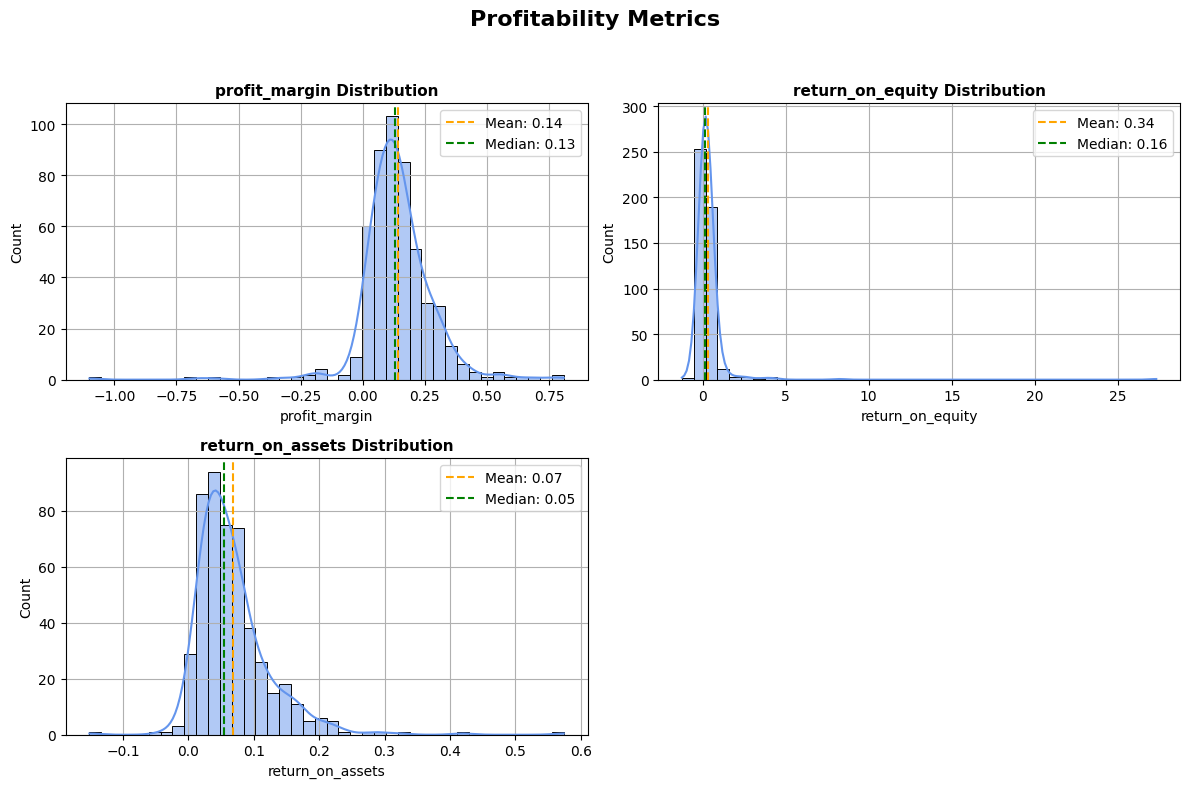

In [33]:
profitability_metrics = ['profit_margin', 'return_on_equity', 'return_on_assets']
check_distribution(fundamentals_df, profitability_metrics, title="Profitability Metrics")

### 💼 Valuation Metrics – Rationale for Selection

Valuation metrics help investors determine whether a stock is overvalued or undervalued relative to its fundamentals. These metrics are key inputs in **stock screening**, **portfolio construction**, and **investment decision-making** for nearly all investor types — from first-time retail investors to institutional portfolio managers.

---

### 📊 Selected Metrics and Their Purpose

- **Trailing P/E (Price-to-Earnings Ratio)**
    - *Definition:* Current share price divided by earnings per share (last 12 months).
    - *Use:* Helps investors understand how much they are paying for $1 of past earnings.
    - *Why We Use It:* Universally used in valuation screens; reflects actual company performance.
- **Forward P/E**
    - *Definition:* Price divided by expected earnings per share (next 12 months).
    - *Use:* Reflects market expectations about a company’s future earnings growth.
    - *Why We Use It:* Important for growth investors and market sentiment interpretation.
- **Price-to-Book (P/B) Ratio**
    - *Definition:* Price per share divided by book value per share (assets minus liabilities).
    - *Use:* Indicates how much investors are paying for the company’s net asset value.
    - *Why We Use It:* Useful for evaluating asset-heavy businesses (e.g., banks, utilities).
- **Price-to-Sales (P/S) Ratio**
    - *Definition:* Market cap divided by total revenue.
    - *Use:* Helps assess valuation independent of profitability.
    - *Why We Use It:* Important for high-growth companies with thin margins or no profit yet.

---

### 👤 Why It Matters for Different Investors

- **First-Time Investors:** Often focus on popular stocks with buzz; P/E helps prevent overpaying for hype.
- **Retail Investors:** Use P/E and P/B filters for value and quality screening.
- **Institutional Managers:** Consider sector-relative valuation and market expectations (Forward P/E and P/S).

---

### 🧠 Key Insights

- These metrics are **often skewed** due to sector differences or market cycles, but that doesn't reduce their relevance.
- Instead of dropping skewed metrics like `trailing_pe`, we apply **log-transformation** and **outlier capping** to prepare them for clustering.
- Valuation ratios are **fundamental to classifying investment styles** such as value, growth, or GARP (growth at a reasonable price).

---

### 📚 References

- Damodaran, A. (2012). *Investment Valuation*. Wiley Finance.
- CFA Institute. (2020). *Equity Investments – Valuation Ratios & Multiples*.
- Morningstar, Yahoo Finance, Investopedia definitions and screening use cases.

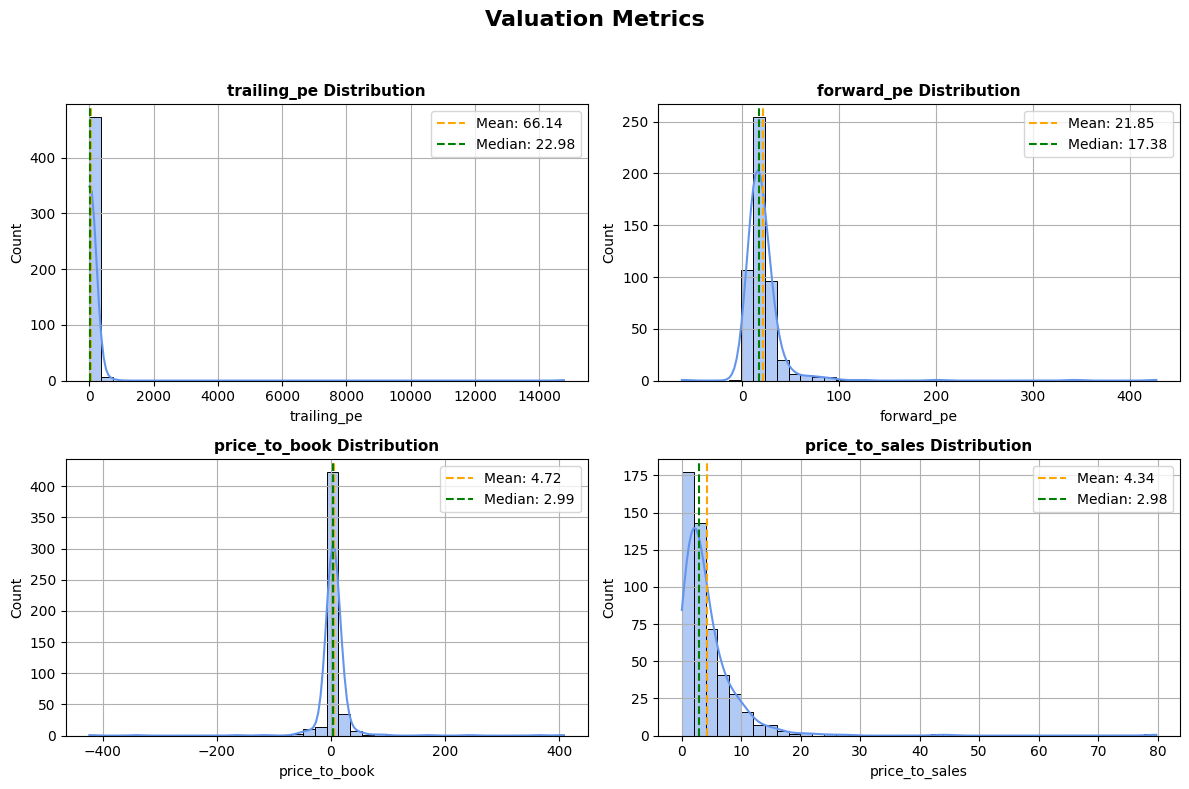

In [34]:
valuation_metrics = ['trailing_pe', 'forward_pe', 'price_to_book', 'price_to_sales']
check_distribution(fundamentals_df, valuation_metrics, title="Valuation Metrics")

### 📈 Growth Metrics – Rationale for Selection

Growth metrics capture a company’s ability to expand its business, revenues, and earnings over time. These indicators are especially important to **growth investors**, **early-stage opportunity seekers**, and **portfolio managers** looking for capital appreciation.

---

### 📊 Selected Metrics and Their Purpose

- **Revenue Growth**
    - *Definition:* Year-over-year percentage change in total revenue.
    - *Use:* Measures the expansion in a company’s sales.
    - *Why We Use It:* It's a foundational indicator of business momentum and product-market fit.
- **EPS Growth (Earnings Per Share Growth)**
    - *Definition:* Percentage increase in earnings per share over time.
    - *Use:* Evaluates profit growth on a per-share basis, accounting for stock buybacks or dilution.
    - *Why We Use It:* EPS is often used by analysts and investors to assess the earnings trajectory, which drives stock price performance.

---

### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May be drawn to fast-growing brands or "story stocks" with high revenue spikes.
- **Retail Investors:** Often use EPS growth in screeners to find outperformers.
- **Institutional Managers:** Look at both revenue and EPS growth in relative terms (vs. sector/benchmark) to spot long-term trends.

---

### 🧠 Key Insights from EDA

- `revenue_growth` is **mildly right-skewed**, mostly centered around 5–7%, with a few high-growth outliers.
- `eps_growth` is **highly right-skewed**, with extreme outliers (1000%+ EPS growth), which can distort clustering.
- These features will likely require **outlier treatment or log transformation** to prevent clustering bias.

---

### 📚 References

- CFA Institute (2020). *Equity Investments – Earnings Analysis*.
- Damodaran, A. (2012). *Investment Valuation*.
- Morningstar, Investopedia, Yahoo Finance data definitions.

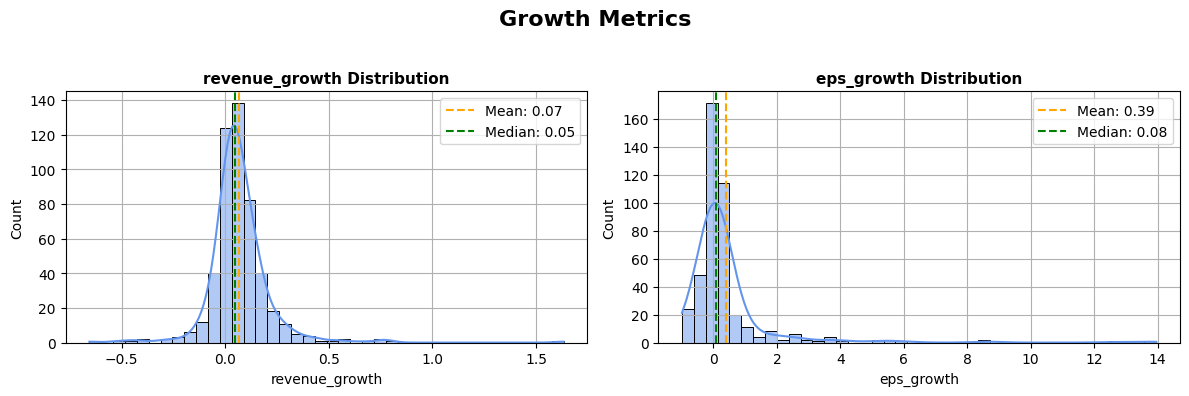

In [35]:
growth_metrics = ['revenue_growth', 'eps_growth']
check_distribution(fundamentals_df, growth_metrics, title="Growth Metrics")

### 💰 Stability & Income Metrics – Rationale for Selection

These metrics assess a company’s ability to manage its **debt obligations**, maintain **liquidity**, and **reward investors with consistent payouts**. They’re highly relevant for **income-seeking**, **risk-averse**, and **long-term conservative investors**.

---

### 📊 Selected Metrics and Their Purpose

- **Dividend Yield**
    - *Definition:* Annual dividend ÷ Share price
    - *Use:* Shows the cash return an investor receives relative to the stock price.
    - *Why We Use It:* Helps identify dividend-paying companies — crucial for income portfolios and retirement strategies.
- **Debt-to-Equity Ratio**
    - *Definition:* Total Liabilities ÷ Shareholders’ Equity
    - *Use:* Indicates how much a company is relying on debt to fund operations.
    - *Why We Use It:* High leverage can signal financial risk. Key in credit risk analysis and identifying volatile or distressed companies.
- **Current Ratio**
    - *Definition:* Current Assets ÷ Current Liabilities
    - *Use:* Measures short-term financial health and liquidity.
    - *Why We Use It:* A ratio below 1.0 indicates potential liquidity issues, while very high values may suggest poor capital deployment.

---

### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May be drawn to dividend-paying stocks for passive income.
- **Retail Investors:** Use current ratio and debt-to-equity to avoid risky or over-leveraged companies.
- **Institutional Managers:** Include these metrics in screening filters and risk-weighted asset models.

---

### 🧠 Key Insights from EDA

- `dividend_yield` shows **moderate right skew**, with a clear cluster between 0–2%. Higher values (5%+) are rare and might indicate undervalued or riskier income stocks.
- `debt_to_equity` is **heavily skewed** due to extreme outliers (e.g. D/E > 8000). This requires **log transformation or outlier capping**.
- `current_ratio` has **moderate skew** and most values are healthy (>1.0). It can be retained with mild transformation or clipping.

---

### 📚 References

- CFA Institute: *Corporate Finance – Working Capital & Capital Structure*
- Damodaran, A. (2012). *Investment Valuation*
- Morningstar & Investopedia financial definitions and risk screening tools

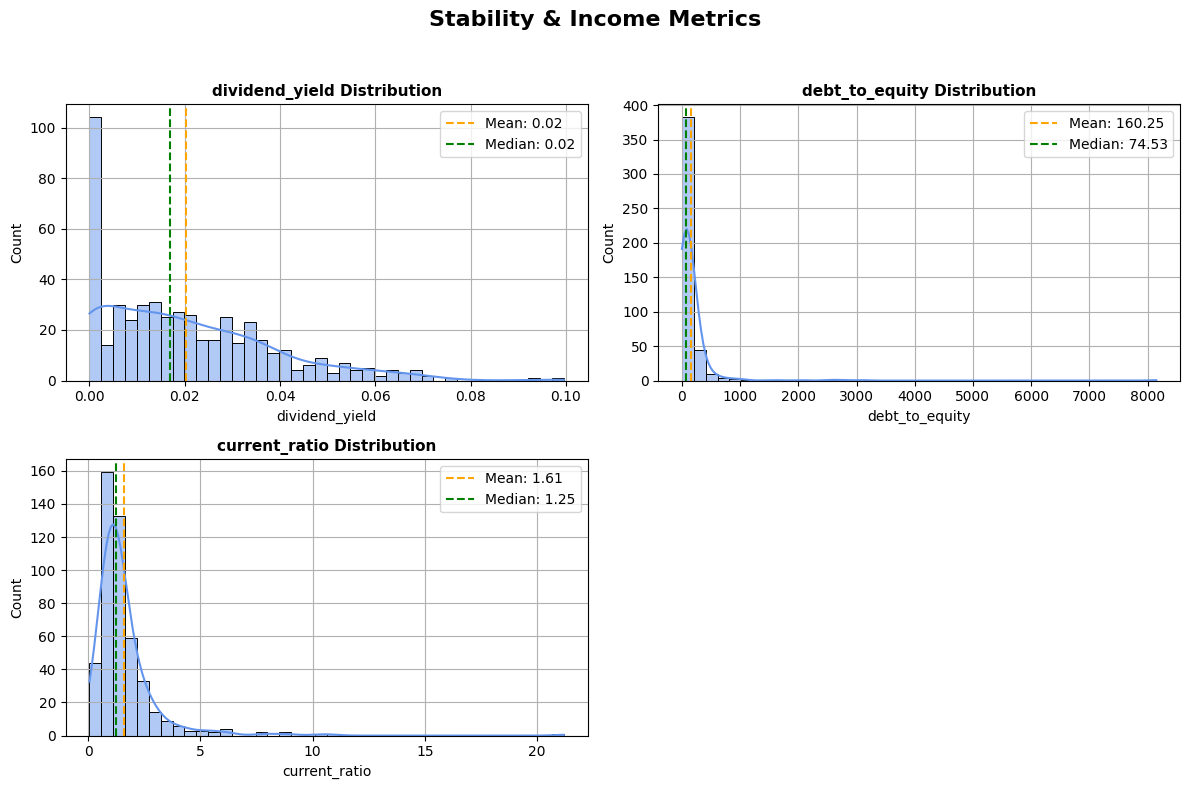

In [36]:
stability_income_metrics = ['dividend_yield', 'debt_to_equity', 'current_ratio']
check_distribution(fundamentals_df, stability_income_metrics, title="Stability & Income Metrics")

### 💸 Cash Flow & Risk/Return Metrics – Rationale for Selection

These metrics assess a company's **financial engine (cash flows)** and how well it performs in the market **relative to its risk**. They are key to evaluating both **internal financial strength** and **external investor appeal** — making them essential for portfolio construction, asset screening, and risk-adjusted performance.

---

### 📊 Selected Metrics and Their Purpose

- **Operating Cash Flow**
    - *Definition:* Cash generated from core business operations.
    - *Use:* Indicates sustainability of operations — more reliable than net income.
    - *Why We Use It:* It highlights companies with real cash-generating power.
- **Free Cash Flow**
    - *Definition:* Operating Cash Flow – Capital Expenditures
    - *Use:* Shows how much cash is truly available for dividends, buybacks, or reinvestment.
    - *Why We Use It:* Favored by value investors and fundamental analysts; reveals long-term strength.
- **Annual Return**
    - *Definition:* 1-year price return of the stock.
    - *Use:* Measures actual investor performance over a recent period.
    - *Why We Use It:* Standard for comparing stock outcomes, used in portfolio backtesting.
- **Volatility**
    - *Definition:* Standard deviation of returns (typically daily or monthly).
    - *Use:* Measures market risk — how much the stock price fluctuates.
    - *Why We Use It:* Critical for balancing risk in portfolio optimization.
- **Sharpe Ratio**
    - *Definition:* (Return – Risk-Free Rate) ÷ Volatility
    - *Use:* Assesses return per unit of risk — the go-to metric for risk-adjusted performance.
    - *Why We Use It:* Used by both retail and institutional investors in fund comparison and stock screening.
- **Beta**
    - *Definition:* Measure of stock volatility relative to the market (S&P 500).
    - *Use:* Beta > 1 = aggressive; Beta < 1 = defensive.
    - *Why We Use It:* Essential for understanding market sensitivity and building balanced portfolios.

---

### 👥 Why It Matters for Different Investors

- **First-Time Investors:** May not track cash flow deeply but rely on risk-adjusted returns to avoid unstable stocks.
- **Retail Investors:** Use volatility and Sharpe Ratio to avoid underperformers or risky bets.
- **Institutional Managers:** Optimize portfolios using metrics like Beta, Sharpe Ratio, and FCF in asset selection and risk allocation.

---

### 🧠 Key Insights from EDA

- `operating_cash_flow` and `free_cash_flow` are **heavily right-skewed** due to mega-cap firms; will need **log transformation**.
- `sharpe_ratio` is wide and includes **negatives**, suggesting underperformance is common — requires **winsorization or transformation**.
- `annual_return` and `beta` are **well-behaved** and centered
- `volatility` shows long tails — **robust scaling** might help.

---

### 📚 References

- CFA Institute (2021): *Portfolio Management and Wealth Planning – Risk & Return*
- Damodaran, A. (2012): *Investment Valuation*
- Morningstar & Investopedia metric definitions
- Black-Litterman and Sharpe (1966) – risk-adjusted return theory

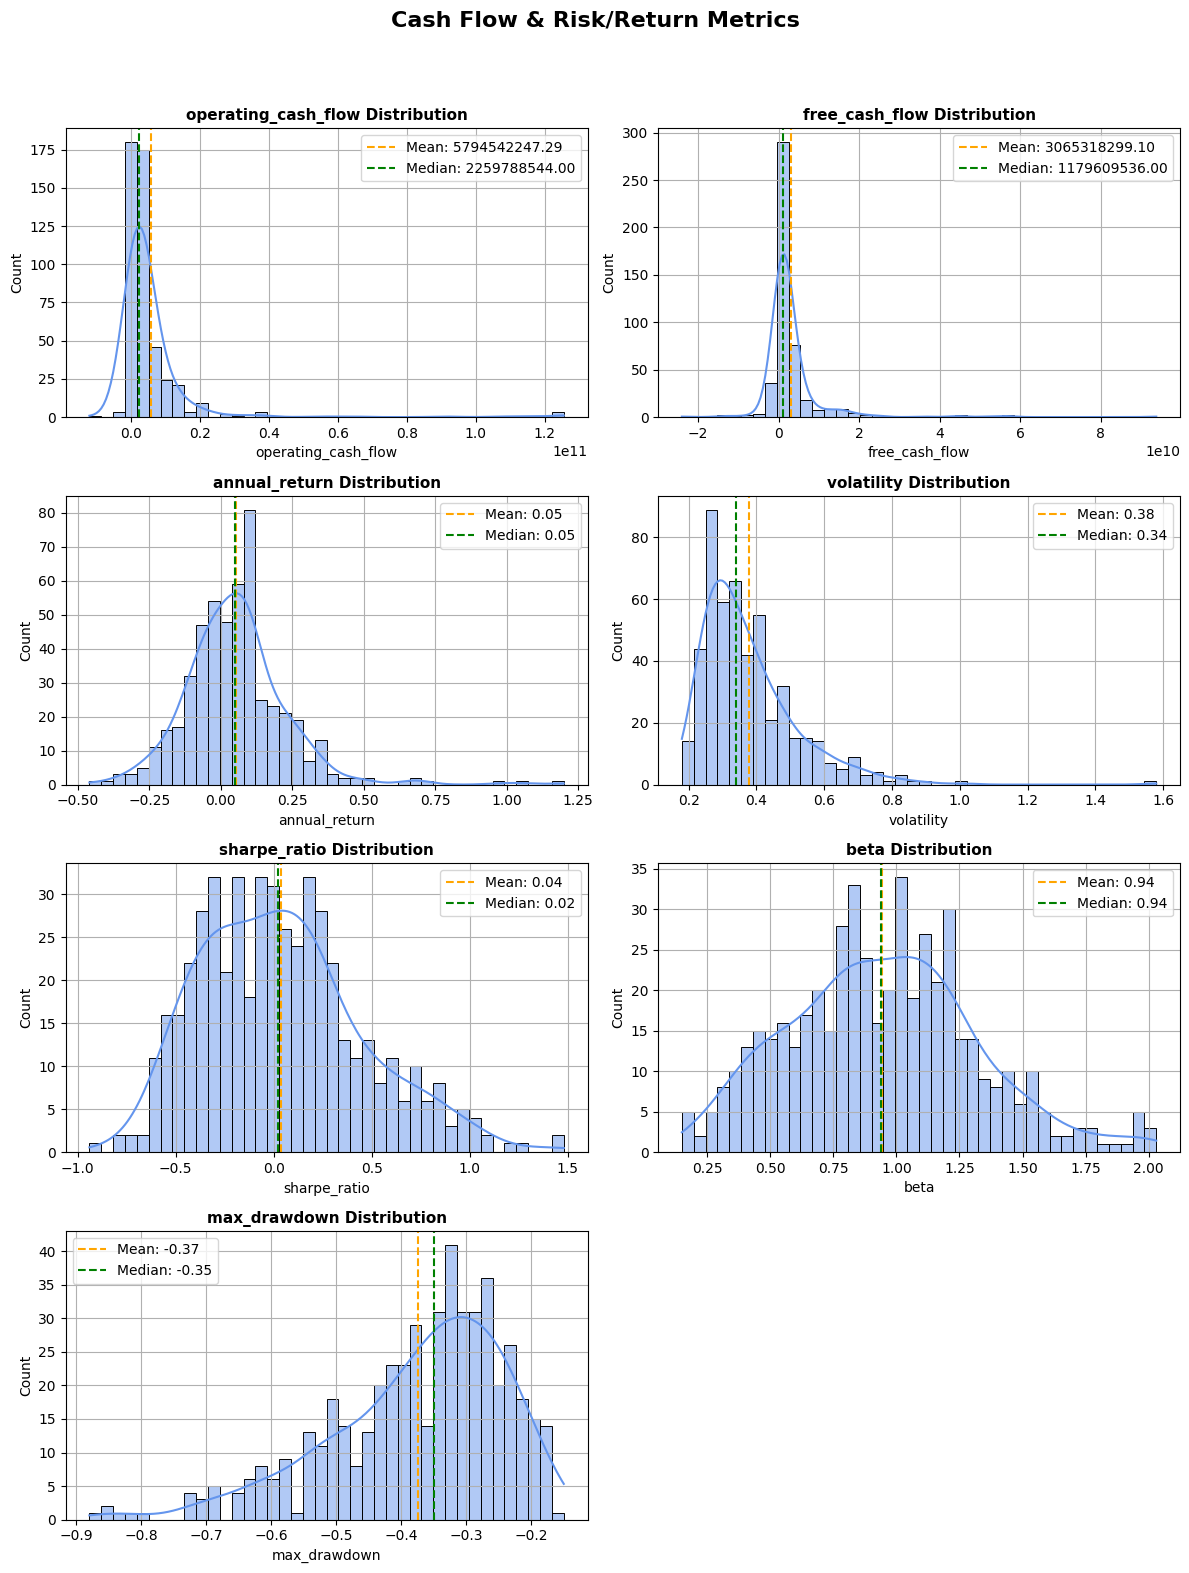

In [37]:
cashflow_risk_metrics = [
    'operating_cash_flow', 
    'free_cash_flow',
    'annual_return', 
    'volatility', 
    'sharpe_ratio', 
    'beta',
    'max_drawdown'
]
check_distribution(merged_df, cashflow_risk_metrics, title="Cash Flow & Risk/Return Metrics")

In [38]:
# Merge the DataFrames
merged_df = pd.merge(fundamentals_df, risk_df, on='stock_id', how='inner')
merged_df = pd.merge(merged_df, sp500_df[['stock_id', 'ticker','sector']], on='stock_id', how = 'inner')
merged_df

# Drop extra features
merged_df = merged_df.drop(['peg_ratio', 'created_at_x', 'created_at_y','market_cap'], axis =1 ).copy()
merged_df

# droping rows where nans are > 6
row_missing = merged_df.isna().sum(axis = 1)
removed_data = merged_df.loc[row_missing >=10]
merged_df = merged_df.loc[row_missing < 10]
merged_df.describe().T


,count,mean,std,min,25%,50%,75%,max
stock_id,501.0,9.102517e+05,1.451700e+02,9.100000e+05,9.101270e+05,9.102520e+05,9.103770e+05,9.105020e+05
trailing_pe,479.0,6.614164e+01,6.757222e+02,4.217300e+00,1.521806e+01,2.298415e+01,3.380492e+01,1.475700e+04
forward_pe,501.0,2.184782e+01,2.834499e+01,-6.207692e+01,1.195628e+01,1.737805e+01,2.438261e+01,4.274063e+02
price_to_book,501.0,4.722406e+00,4.010967e+01,-4.234534e+02,1.637962e+00,2.985604e+00,6.432572e+00,4.083030e+02
price_to_sales,501.0,4.340215e+00,5.410832e+00,6.254610e-02,1.497514e+00,2.978432e+00,5.507872e+00,7.975039e+01
profit_margin,501.0,1.407867e-01,1.450893e-01,-1.100430e+00,7.259000e-02,1.283200e-01,2.016600e-01,8.095200e-01
return_on_equity,468.0,3.436388e-01,1.388808e+00,-1.249360e+00,8.867250e-02,1.600350e-01,2.943900e-01,2.731250e+01
return_on_assets,494.0,6.804316e-02,5.862790e-02,-1.514100e-01,3.028500e-02,5.497500e-02,8.718000e-02,5.741700e-01
revenue_growth,499.0,6.801202e-02,1.523747e-01,-6.560000e-01,3.500000e-03,4.900000e-02,1.145000e-01,1.634000e+00
eps_growth,426.0,3.910047e-01,1.542287e+00,-9.940000e-01,-1.177500e-01,7.650000e-02,3.115000e-01,1.395700e+01


## 2.1  Sector Analysis
For each GICS sector we calculate the median P/E, P/B, ROA, and so on.

Why do this?

1. **Spot sector bias** – Banks sit near 12 × P/E, while software firms hover around 25 ×. If we feed raw P/E into the model, clusters would simply mirror “bank vs. tech” instead of revealing multi‑factor styles.
2. **Decide which features to neutralise** – Big gaps (e.g. Real Estate median P/E ≈ 37 × vs. Energy ≈ 14 ×) tell us that a metric needs sector‑standardising so distances depend on *relative* not absolute values.
3. **Catch outliers and data quirks** – A negative median free‑cash‑flow margin for Utilities alerts us to its capital‑heavy nature. It also guides imputation: a missing current‑ratio in Materials should use the Materials median rather than the Consumer‑Staples median (~1.3).

In [39]:
import math
def sector_comparision(data, feature):
    ncols = 4
    nrows = math.ceil(len(feature) / ncols)


    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
    axes = axes.flatten()
    for ax, feat in zip(axes, feature):
        sns.barplot(x='sector', y=feat, data=data, ax=ax, color='cornflowerblue')
        ax.set_title(feat,fontsize=12)
        ax.tick_params(axis='x', rotation=90, labelsize=10)     # smaller labels
        ax.tick_params(axis='y', labelsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('Median', fontsize=8)

    for ax in axes[len(feature):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

In [40]:
def outlier_detection(data):

    plt.figure(figsize=(12,10))

    for i, j in enumerate(data.describe().columns):
        plt.subplot(5,5, i+1)
        sns.boxplot(x=data[j])
        plt.title('{}'.format(j))
        plt.tight_layout()
    
    #plt.savefig('box.png')
    plt.show()

2.3   Sector Analysis
A few patterns jump out:

| Theme | Observation | What it means |
|-------|-------------|---------------|
| **Valuation** | Real Estate tops all three price‐based multiples (P/E ≈ 35×, P/B ≈ 3.5×, P/S ≈ 8×), while Energy and Financials sit at the low end (P/E ≈ 12–14×). | Multiples alone would split stocks into “expensive REITs vs. cheap banks/oil,” so we need to scale by sector. |
| **Profitability** | Tech posts the fattest margins (profit ≈ 18 %, ROA ≈ 10 %), Utilities the thinnest. | Confirms fundamental logic—capital‑light software vs. capital‑heavy infrastructure. |
| **Growth** | Financials show a spike in EPS growth (> 60 %) after rate‑cycle windfalls, whereas Energy’s revenue trend is down. | Raw growth metrics are noisy and sector‑skewed; neutralisation is mandatory. |
| **Leverage** | Utilities carry the heaviest debt‑to‑equity (> 2×); Tech and Health Care remain below 0.6×. | Sector medians guide imputation and highlight leverage risk. |
| **Liquidity** | Real Estate boasts the highest current ratio (~1.8); Financials essentially zero (banks’ balance‑sheet structure). | Reinforces that a single median fill value makes no sense across sectors. |
| **Risk / Return** | Tech earns the best Sharpe (> 1) and the highest beta (~1.3); Utilities display defensive traits: low beta (~0.3), lower drawdown. | Sector patterns echo classic factor lore and justify z‑scoring.

**Take‑away:** Sector medians differ so much that clustering on *raw* values would mostly reproduce the GICS grid. We therefore apply the sector‑neutral z‑scaling pipeline (see § 2.2) before K‑Means so clusters capture cross‑factor style rather than industry identity.

C:\Users\mrina\AppData\Local\Temp\ipykernel_19048\905088737.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


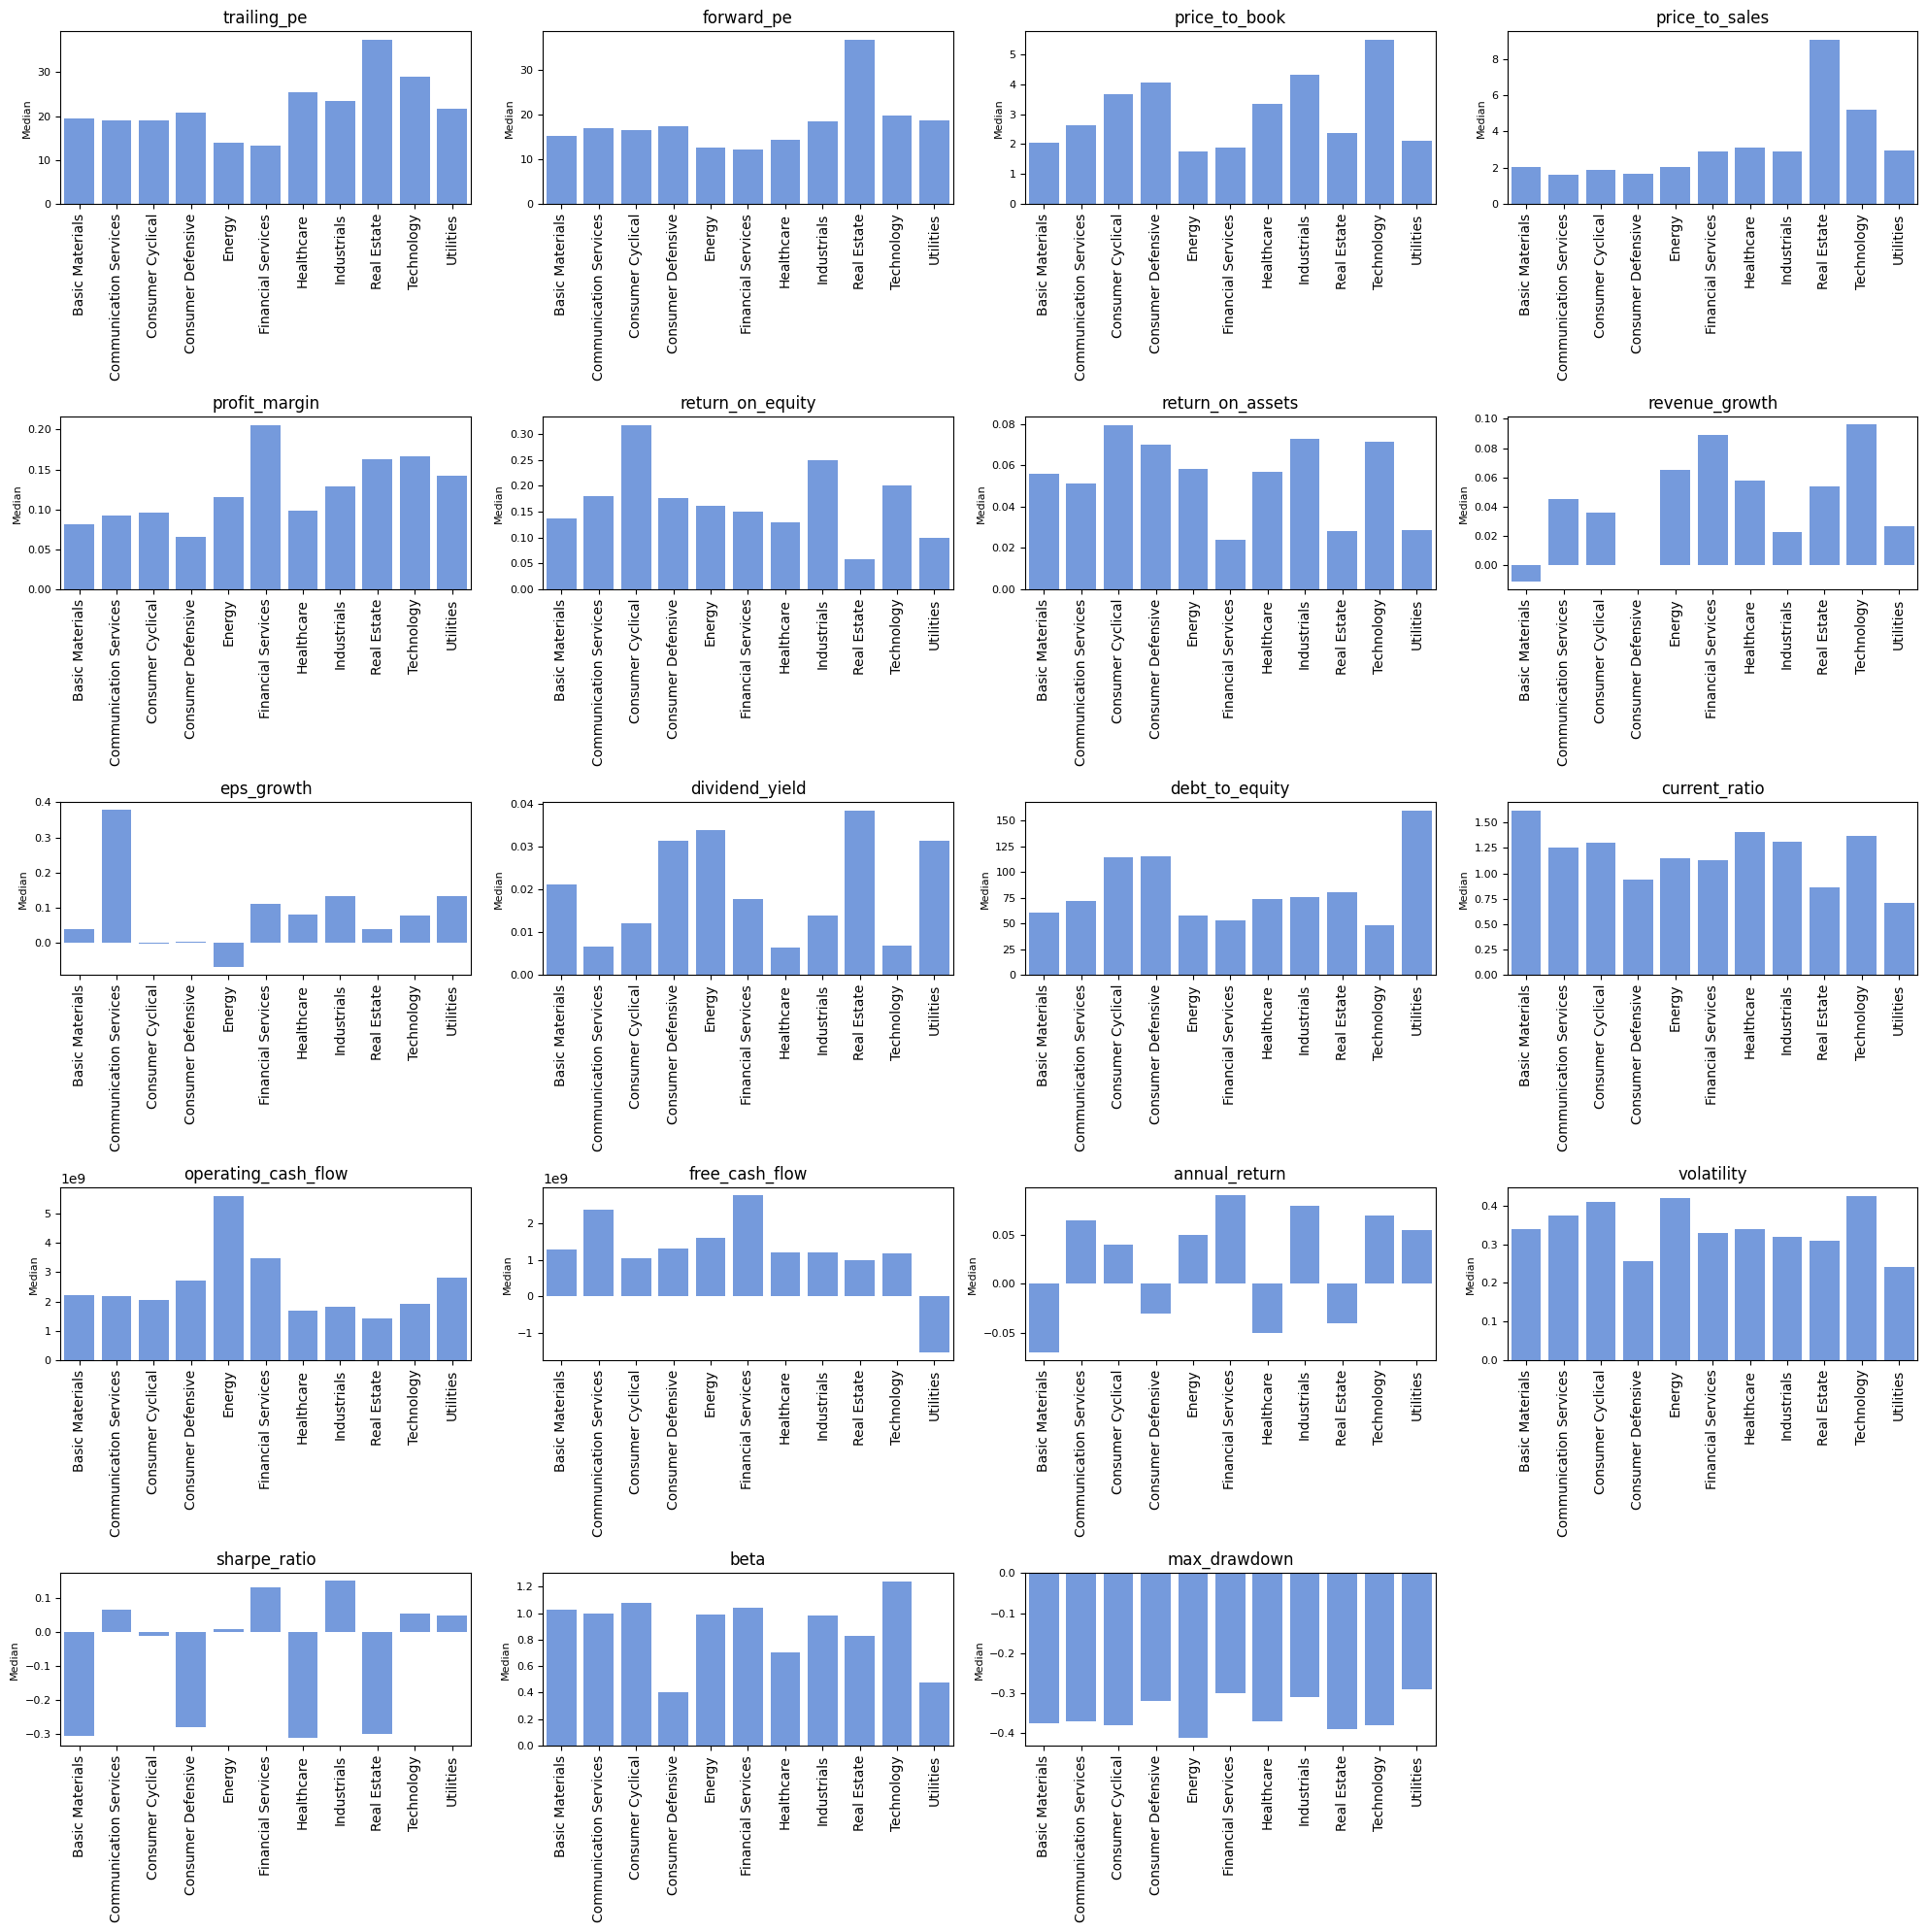

In [41]:
# Sector wise comparision median data as mean will be susceptible to outliers
feature = merged_df.columns[0:-2].tolist()
median_df = merged_df.groupby('sector')[feature].median().reset_index()
features = merged_df.columns[1:-2].tolist()
sector_comparision(median_df, features)

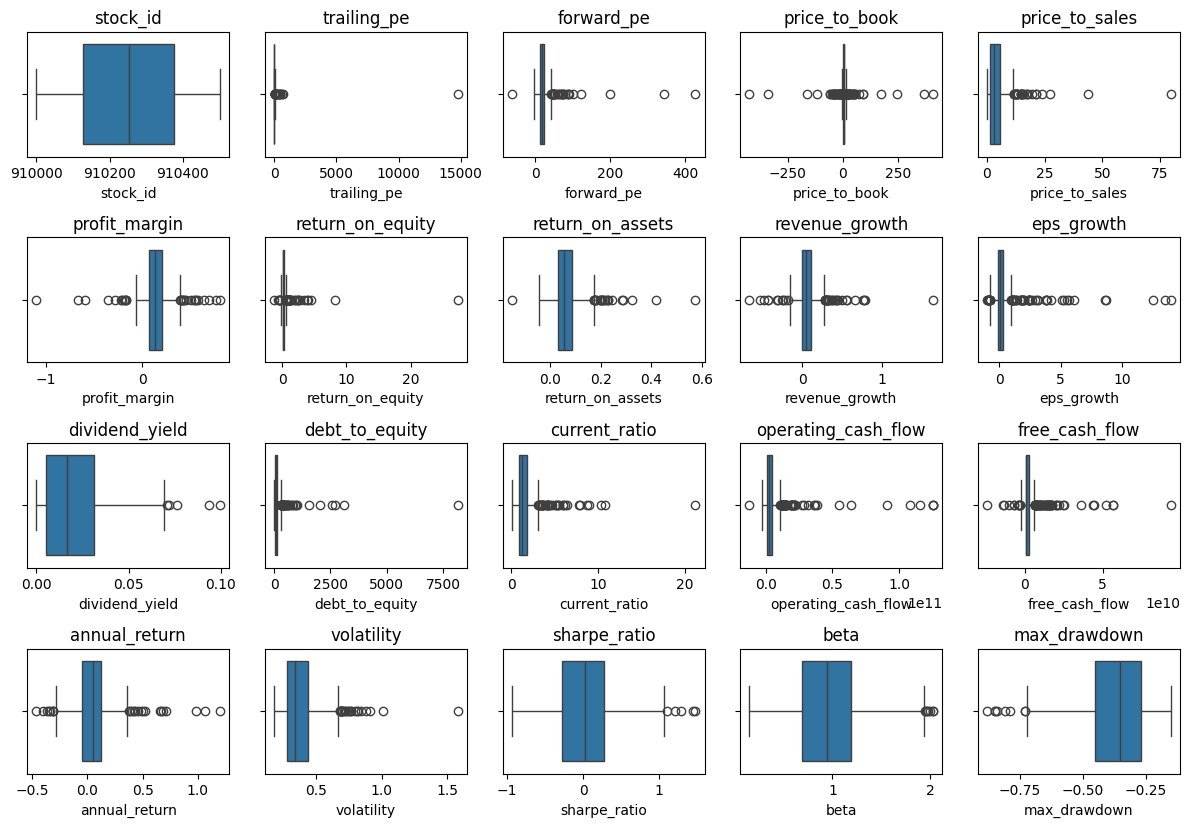

In [42]:
outlier_detection(merged_df)

In [43]:
sector_list = merged_df.sector.unique().tolist()
features = ['trailing_pe', 'forward_pe', 'price_to_book',
       'price_to_sales', 'profit_margin', 'return_on_equity',
       'return_on_assets', 'revenue_growth', 'eps_growth', 'dividend_yield',
       'debt_to_equity', 'current_ratio', 'operating_cash_flow',
       'free_cash_flow', 'annual_return', 'volatility', 'sharpe_ratio', 'beta',
       'max_drawdown']

In [44]:
merged_df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
trailing_pe,479.0,6.614164e+01,6.757222e+02,4.217300e+00,1.521806e+01,2.298415e+01,3.380492e+01,1.475700e+04
forward_pe,501.0,2.184782e+01,2.834499e+01,-6.207692e+01,1.195628e+01,1.737805e+01,2.438261e+01,4.274063e+02
price_to_book,501.0,4.722406e+00,4.010967e+01,-4.234534e+02,1.637962e+00,2.985604e+00,6.432572e+00,4.083030e+02
price_to_sales,501.0,4.340215e+00,5.410832e+00,6.254610e-02,1.497514e+00,2.978432e+00,5.507872e+00,7.975039e+01
profit_margin,501.0,1.407867e-01,1.450893e-01,-1.100430e+00,7.259000e-02,1.283200e-01,2.016600e-01,8.095200e-01
return_on_equity,468.0,3.436388e-01,1.388808e+00,-1.249360e+00,8.867250e-02,1.600350e-01,2.943900e-01,2.731250e+01
return_on_assets,494.0,6.804316e-02,5.862790e-02,-1.514100e-01,3.028500e-02,5.497500e-02,8.718000e-02,5.741700e-01
revenue_growth,499.0,6.801202e-02,1.523747e-01,-6.560000e-01,3.500000e-03,4.900000e-02,1.145000e-01,1.634000e+00
eps_growth,426.0,3.910047e-01,1.542287e+00,-9.940000e-01,-1.177500e-01,7.650000e-02,3.115000e-01,1.395700e+01
dividend_yield,501.0,2.021130e-02,1.808279e-02,0.000000e+00,5.417485e-03,1.682760e-02,3.122663e-02,9.957325e-02


## 2.2 Missing Value

In [ ]:
# Check for missing values
print("🔍 Missing values in selected features:")
print(merged_df[features].isnull().sum())

#Check for problematic values (e.g. zero or negative before log-transform)
print("\n🚨 Zero or negative values:")
for col in features:
    print(f"{col}: {(merged_df[col] < 0).sum()} zero/negative values")


🔍 Missing values in selected features:
trailing_pe            22
forward_pe              0
price_to_book           0
price_to_sales          0
profit_margin           0
return_on_equity       33
return_on_assets        7
revenue_growth          2
eps_growth             75
dividend_yield          0
debt_to_equity         51
current_ratio          25
operating_cash_flow    25
free_cash_flow         33
annual_return           0
volatility              0
sharpe_ratio            0
beta                    0
max_drawdown            0
dtype: int64

🚨 Zero or negative values (pre-log candidates):
trailing_pe: 0 zero/negative values
forward_pe: 2 zero/negative values
price_to_book: 32 zero/negative values
price_to_sales: 0 zero/negative values
profit_margin: 22 zero/negative values
return_on_equity: 19 zero/negative values
return_on_assets: 8 zero/negative values
revenue_growth: 121 zero/negative values
eps_growth: 165 zero/negative values
dividend_yield: 0 zero/negative values
debt_to_equity: 0

In [46]:
#median_df.set_index('sector', inplace= True)
median_df[['return_on_assets','debt_to_equity','current_ratio','free_cash_flow','revenue_growth']]

,return_on_assets,debt_to_equity,current_ratio,free_cash_flow,revenue_growth
0,0.055860,60.4855,1.6200,1.274875e+09,-0.0110
1,0.051245,71.9710,1.2505,2.358062e+09,0.0455
2,0.079580,114.9515,1.3020,1.051250e+09,0.0360
3,0.070030,115.5830,0.9390,1.303982e+09,0.0005
4,0.058410,58.1610,1.1520,1.595500e+09,0.0650
5,0.023900,52.9710,1.1285,2.758725e+09,0.0890
6,0.056830,73.8555,1.4110,1.197112e+09,0.0580
7,0.072680,75.6290,1.3160,1.195125e+09,0.0230
8,0.028460,80.5995,0.8650,1.002340e+09,0.0540
9,0.071610,48.2770,1.3735,1.173069e+09,0.0960


## Data preprocessing

**Sector‑median imputation** — fill missing values with the median of the stock’s own sector peers (e.g. a utility missing debt‑to‑equity inherits the utilities median).  
   *Metrics with > 10 % missingness (e.g. EPS growth) are dropped.*

In [47]:
missing_features = ['trailing_pe','return_on_equity','return_on_assets','debt_to_equity','current_ratio','free_cash_flow','revenue_growth','operating_cash_flow']

clean_data = merged_df[features].copy()
clean_data['sector'] = merged_df['sector']


for col in missing_features:
    # This line fills NaNs within each sector with that sector's median.
    clean_data[col] = clean_data.groupby('sector')[col].transform(lambda x: x.fillna(x.median()))
    

In [48]:
#print(clean_data[selected_features].isnull().sum())
    # Sector Neutralization - To remove sector bias - Median of each sector
#_clean_data = clean_data.copy()
#for feature in selected_features:
#    neutralized_data= _clean_data.groupby('sector')[feature].transform(lambda x: x - x.median())
#    _clean_data[feature] = neutralized_data
        

for col in features:
    print(f"{col}: {(clean_data[col] == 0).sum()} zero/negative values")

clean_data['revenue_growth'].min()


trailing_pe: 0 zero/negative values
forward_pe: 0 zero/negative values
price_to_book: 0 zero/negative values
price_to_sales: 0 zero/negative values
profit_margin: 0 zero/negative values
return_on_equity: 0 zero/negative values
return_on_assets: 0 zero/negative values
revenue_growth: 0 zero/negative values
eps_growth: 1 zero/negative values
dividend_yield: 96 zero/negative values
debt_to_equity: 0 zero/negative values
current_ratio: 0 zero/negative values
operating_cash_flow: 0 zero/negative values
free_cash_flow: 0 zero/negative values
annual_return: 10 zero/negative values
volatility: 0 zero/negative values
sharpe_ratio: 0 zero/negative values
beta: 0 zero/negative values
max_drawdown: 0 zero/negative values


np.float64(-0.656)

## Transformation 

**Yeo‑Johnson power transform** — combats heavy tails while accommodating zeros and negatives.

In [49]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import QuantileTransformer

def yeo_transforn(data,selected_features):
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    _transformed_data = [pt.fit_transform(data[selected_features])]
    return _transformed_data, pt.lambdas_

def robust_scaler(data):
    scaler = RobustScaler(quantile_range=(1,99))
    scaled = scaler.fit_transform(data)
    #for feat, scale in zip(data.columns, scaler.scale_):
        #print(f"{feat}: IQR = {scale:.3f}")
    
    return scaled

def quantile_scaler(data):
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=200, random_state=42)
    data_qt = qt.fit_transform(data)
    return data_qt

def Standard_scaler(data):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)
    return X_scaled

In [108]:
# Trying log transformation before for columns price to book, free cash flow and debt to equity (Ignore)
new_data = clean_data.copy()
from sklearn.preprocessing import FunctionTransformer
positive_vals_feature = ['debt_to_equity', 'price_to_sales','current_ratio']    # need to shift x>0
negative_vals_feature = [ 'revenue_growth', 'return_on_assets', 'profit_margin', 'volatility', 'annual_return']
eps = 1e-6
deltas = new_data[negative_vals_feature].min(axis=0).abs()+ eps

plain_log_tf = FunctionTransformer(
    func = lambda X: np.log1p(X),
    inverse_func = lambda X: np.expm1(X) - deltas,
    validate= False
)

shift_log_tf = FunctionTransformer(
    func=lambda X: np.log1p(X + deltas),
    inverse_func=lambda X: np.expm1(X) - deltas,
    validate=False
)

new_data[positive_vals_feature] = plain_log_tf.transform(new_data[positive_vals_feature])
new_data[positive_vals_feature]
print(new_data[positive_vals_feature].skew())
#check_distribution(clean_data, positive_vals_feature)
#check_distribution(new_data, positive_vals_feature)

debt_to_equity   -0.2657
price_to_sales    0.4570
current_ratio     1.5326
dtype: float64


In [51]:
# New data represents the transformed data.

#feature_for_transfromation = ['forward_pe','price_to_book','price_to_sales','profit_margin','return_on_assets','revenue_growth',
# 'dividend_yield','debt_to_equity','current_ratio','free_cash_flow','annual_return','volatility','max_drawdown']
_transformed_data, _lambda = yeo_transforn(clean_data[features].copy(), features)

_power_transformed = pd.DataFrame(_transformed_data[0], columns= features)
_power_transformed[['beta','sharpe_ratio']] = clean_data[['beta','sharpe_ratio']]

raw_skew = pd.DataFrame(clean_data, columns= features).skew()   
tf_skew  = pd.DataFrame(_power_transformed, columns= features).skew().abs()
print(pd.concat([raw_skew, tf_skew], axis=1, keys=['Initial','Transformed']))
#check_distribution(_power_transformed, features)

                       Initial  Transformed
trailing_pe          22.083312     0.065251
forward_pe            9.540613     3.250390
price_to_book         0.155045     2.789511
price_to_sales        6.899332     0.020574
profit_margin        -1.155455     0.310460
return_on_equity     16.895286     2.211757
return_on_assets      2.542493     0.431972
revenue_growth        2.607004     0.327370
eps_growth            5.553099     0.273175
dividend_yield        1.013759     0.144491
debt_to_equity       13.045521     0.035548
current_ratio         5.985924     0.046796
operating_cash_flow   6.756228     5.513256
free_cash_flow        5.917730     4.388737
annual_return         1.401988     0.084614
volatility            2.231740     0.131223
sharpe_ratio          0.591328     0.591328
beta                  0.322363     0.322363
max_drawdown         -0.951692     0.061717


## Sector-neutral robust scaling — *sector-by-sector centring plus IQR scaling*  

| Step | Formula | Purpose |
|------|---------|---------|
| Centre | (x' = x - median_sector) | Removes level differences; 0 now means “typical firm in its own sector.” |
| Scale  | (z = x'/IQR_sector) | Expresses every value in **sector IQR units**, a robust spread measure immune to outliers. |

**Why we do this**  
- **Eliminate sector bias** – prevents K-Means from simply rebuilding the GICS grid.  
- **Tame outliers** – IQR ignores the noisiest tails, so extreme points can’t warp distances.  
- **Future-proof** – medians and IQRs update with each data refresh, adapting to regime shifts (e.g. rising P/Es in Tech).  
- **Common numeric scale** – a +2 z now means “two sector-IQRs above the median,” regardless of metric.

*Intuition*: after this transform, K-Means compares **relative factor tilts** across industries, not raw ratio levels.


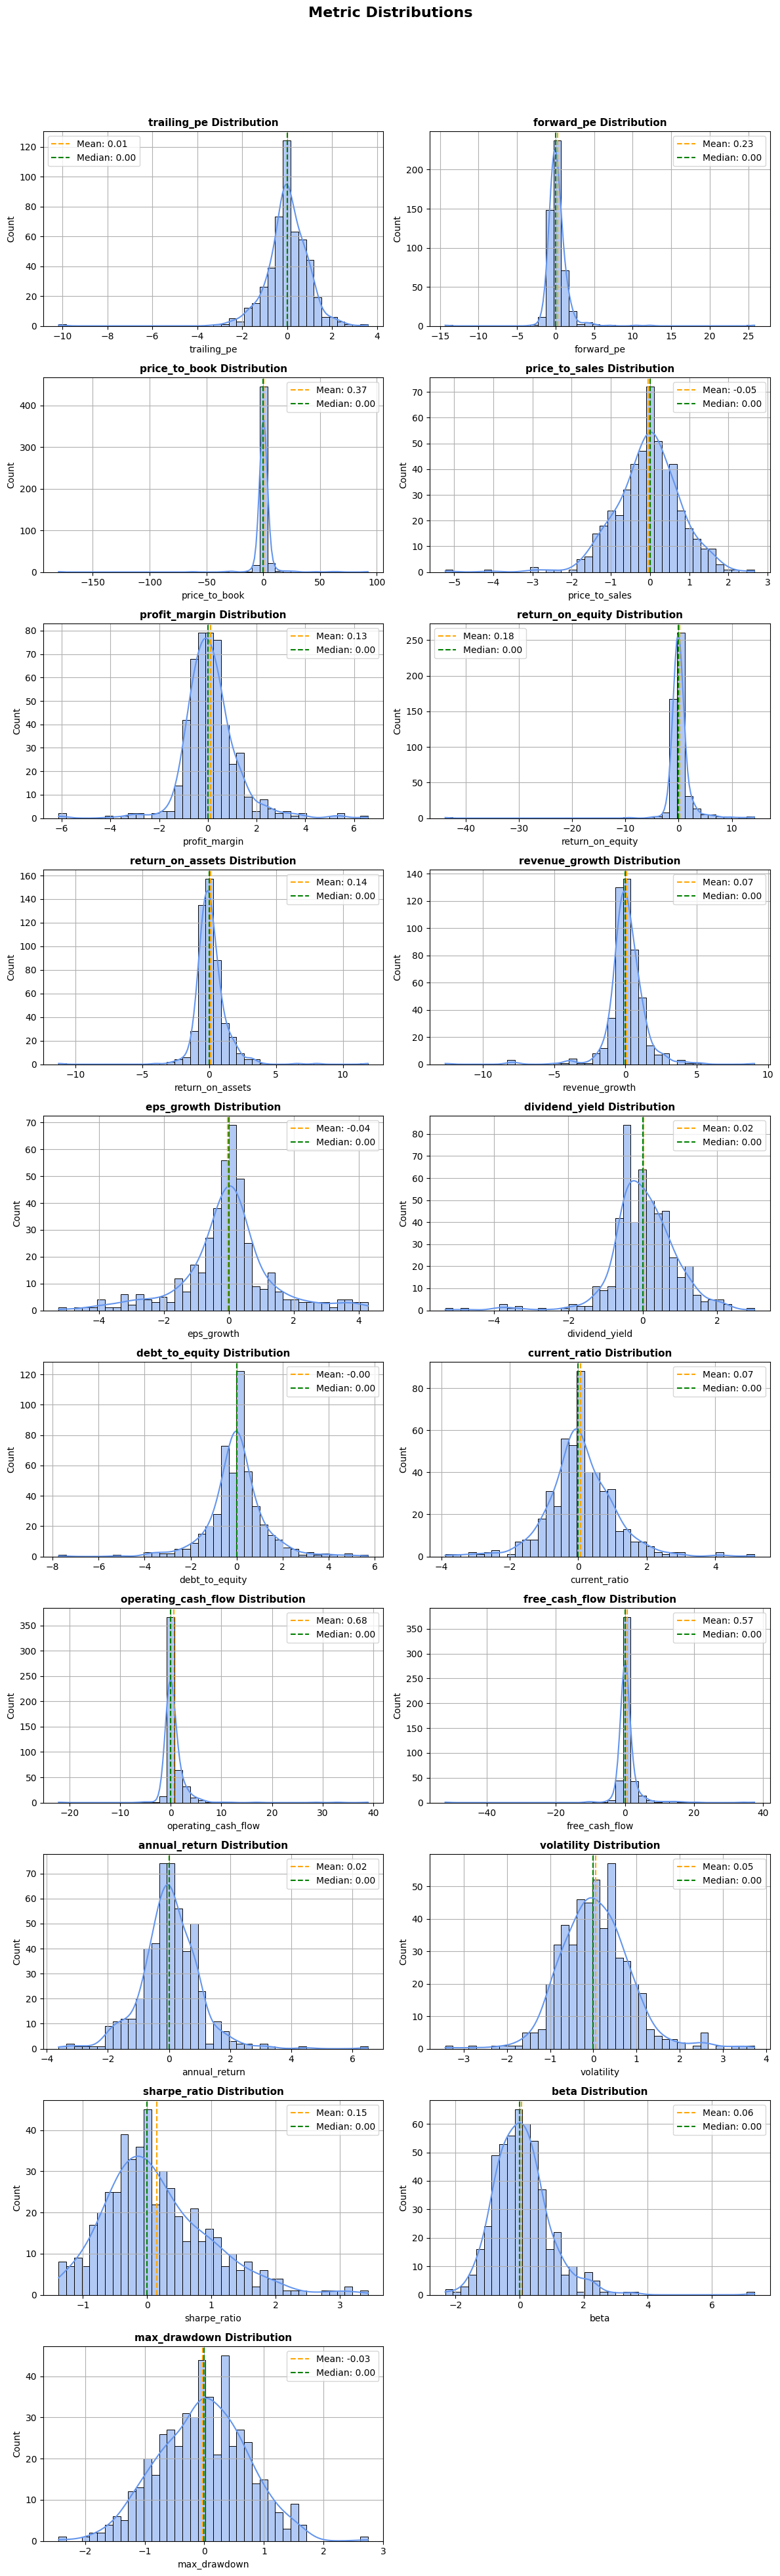

In [52]:
_neutralized_data = _power_transformed.copy()
_neutralized_data['sector'] = clean_data['sector']
for feature in features:
    neutralized_data= _neutralized_data.groupby('sector')[feature].transform(lambda x: (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25)))
    _neutralized_data[feature] = neutralized_data
        
check_distribution(_neutralized_data, features)

In [129]:
# Sanity check for sector neutralzed data
#print(_neutralized_data.groupby('sector')[features].agg(lambda x: x.quantile(0.75) - x.quantile(0.25)))

In [56]:
_power_transformed['sector'] = clean_data['sector']

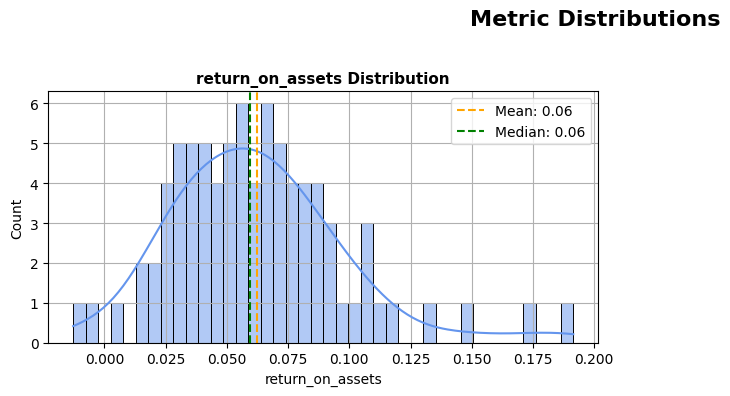

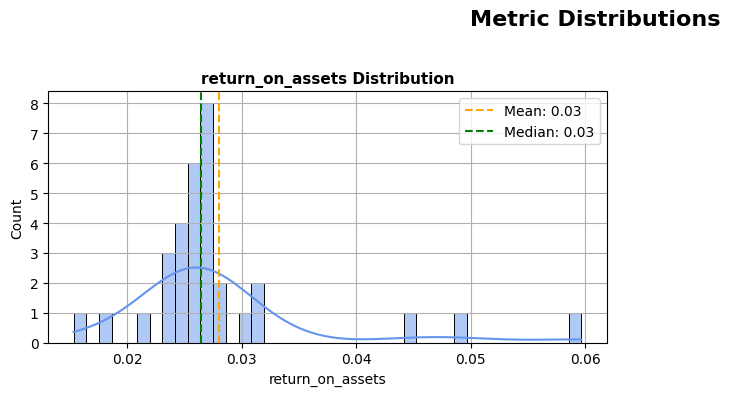

In [57]:
pe_tech_yeo = _power_transformed[_power_transformed['sector'] == 'Technology']
#pe_real_estate = merged_df[merged_df['sector'] == 'Real Estate']
pe_utilities_yeo = _power_transformed[_power_transformed['sector'] == 'Utilities']
check_distribution(pe_tech_yeo, ['return_on_assets'])
check_distribution(pe_utilities_yeo, ['return_on_assets'])

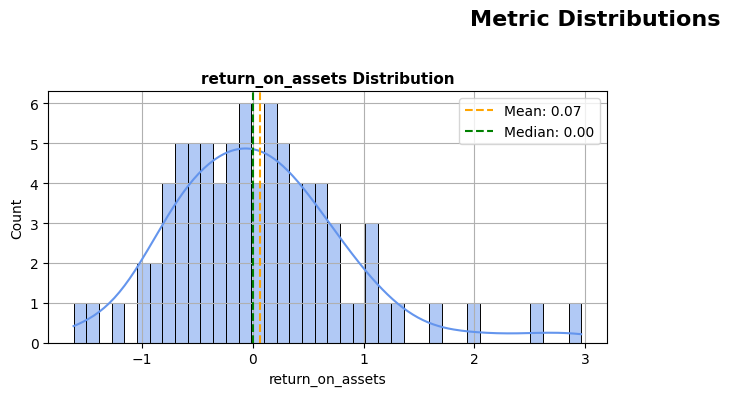

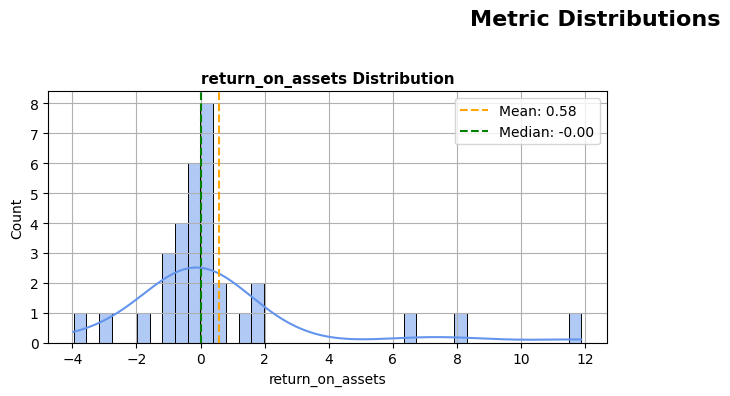

In [58]:
pe_tech_neutral = _neutralized_data[_neutralized_data['sector'] == 'Technology']
pe_real_estate_eutral = _neutralized_data[_neutralized_data['sector'] == 'Real Estate']
pe_utilities_neutral = _neutralized_data[_neutralized_data['sector'] == 'Utilities']
check_distribution(pe_tech_neutral, ['return_on_assets'])
check_distribution(pe_utilities_neutral, ['return_on_assets'])

## Feature Selection

### Feature Selection — Spread Ratio
To keep only metrics that show meaningful variation after cleaning, we score each one with a simple **spread ratio**:


Spread rati = IQR/Max - Min


- **What it tells us**  A larger value means the middle 50 % of stocks already spans a good slice of the total range, so the metric separates *typical* companies—not just the outliers.
- **What we did**  We kept a metric only if its spread ratio exceeded **0.04** (4 %). Anything lower was too flat and was dropped. This rule cut the feature set from 21 down to a lean core that genuinely distinguishes stocks.


In [130]:
pd.options.display.float_format = '{:.4f}'.format
def flat_feature_check(data, features, trim = 0.25, iqr_cut = 0.02, cv_cut = 0.3):
    Q1 = data[features].quantile(0.25)
    Q3 = data[features].quantile(0.75)
    min_ = data[features].min()
    max = data[features].max()
    _range = max - min_
    IQR = Q3 - Q1
    iqr_ratio = IQR / _range
    mask = iqr_ratio < iqr_cut
    data = pd.concat([min_, max, Q1, Q3, IQR, _range,iqr_ratio, mask], axis=1)
    data.rename(columns={0: 'Min', 1: 'Max', 0.25: 'Q1', 0.75: 'Q3', 2: 'IQR', 3: 'Range', 4: 'iqr_ratio', 5:'Middle 50% tight lump huge tail'}, inplace=True)
    return data

C:\Users\mrina\AppData\Local\Temp\ipykernel_19048\3951656644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


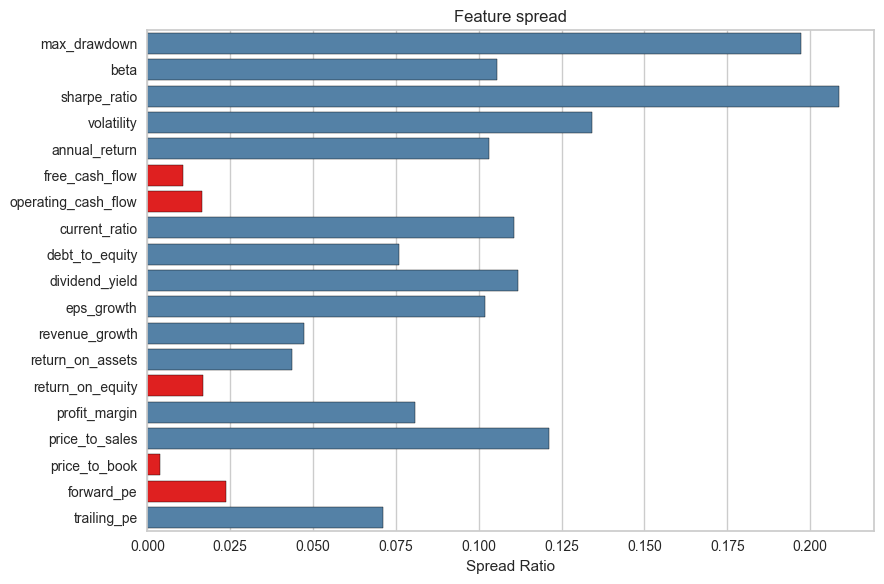

In [131]:
flat_data = flat_feature_check(_neutralized_data, features, iqr_cut=0.04)
plt.figure(figsize=(9, 6))
colors = flat_data["Middle 50% tight lump huge tail"].map(
    {True: "red", False: "steelblue"}).tolist()
sns.barplot(
    data = flat_data,
    y= flat_data.index,
    x='iqr_ratio',
    palette= colors,
    edgecolor="black"
)
plt.xlabel("Spread Ratio")
plt.ylabel("")
plt.title("Feature spread")
plt.gca().invert_yaxis()        # put widest spread at the top
plt.tight_layout()
plt.show()


In [60]:
final_data = _neutralized_data.copy()
final_data.drop(['price_to_book', 'free_cash_flow','forward_pe', 'operating_cash_flow', 'return_on_equity','eps_growth', 'sector' ], axis=1, inplace=True)
final_data

,trailing_pe,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,annual_return,volatility,sharpe_ratio,beta,max_drawdown
0,-0.4345,0.0621,0.4553,-0.2431,-0.2308,0.9142,1.9083,0.1378,-0.0508,0.3874,-0.1410,-0.6667,-0.6645
1,-0.5822,-0.1954,0.1236,0.9407,-1.0895,0.4889,-2.0598,0.3240,-0.3151,0.0000,-0.3877,-0.3784,-0.2415
2,-0.6160,0.3847,1.5858,0.0000,-0.2348,0.5874,-0.8885,0.0000,0.7043,-0.9371,0.8261,-0.2432,0.6822
3,1.1980,0.3972,-0.1494,0.7687,-0.0259,1.2948,3.8902,-1.3860,0.7634,-0.7134,0.8913,-0.8378,1.0521
4,-0.2698,-0.5847,-0.4470,0.6028,-0.3249,0.6364,-0.4144,0.0871,-0.4816,-0.6763,-0.6386,-0.4494,0.5424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.4352,0.1082,-0.2646,-0.5634,0.4273,-0.0391,-1.3997,0.5588,0.1971,-0.2213,0.1762,0.0901,0.1737
497,0.6709,1.0144,1.4477,1.4042,1.0903,0.2902,0.0000,0.1992,0.1227,-1.5190,0.2342,-1.0602,1.5289
498,-0.3410,-0.6865,-0.5177,-0.1404,1.5615,-0.4037,0.2238,0.0502,-1.4211,0.3893,-1.0964,0.5169,-0.5721
499,-0.2318,-0.1299,0.1332,-0.3128,-0.1954,0.2080,-0.3552,0.5329,-0.1395,-0.6092,-0.2391,0.1622,0.2542


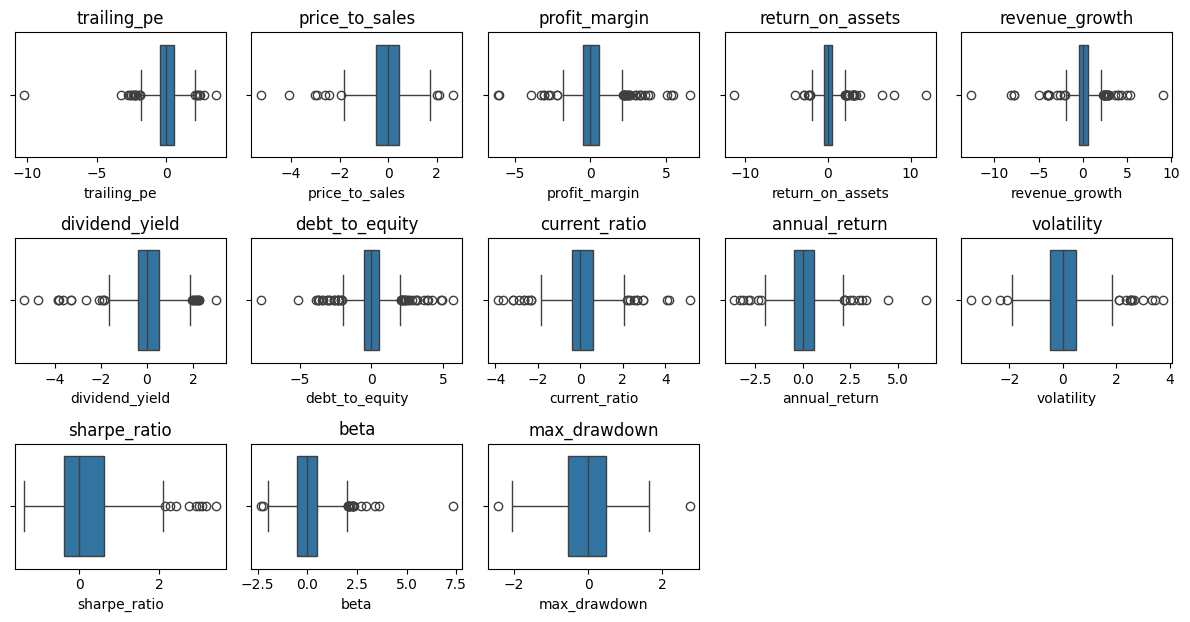

In [61]:
outlier_detection(final_data)

## Winsorisation (±5 z)** — clips the outer ±1 % tails to stop outliers from dragging centroids.

In [62]:
# Wizorize data
# Flag part remaining
X_clipped = final_data.apply(lambda s: s.clip(-5, 5)).copy()
X_clipped

,trailing_pe,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,annual_return,volatility,sharpe_ratio,beta,max_drawdown
0,-0.4345,0.0621,0.4553,-0.2431,-0.2308,0.9142,1.9083,0.1378,-0.0508,0.3874,-0.1410,-0.6667,-0.6645
1,-0.5822,-0.1954,0.1236,0.9407,-1.0895,0.4889,-2.0598,0.3240,-0.3151,0.0000,-0.3877,-0.3784,-0.2415
2,-0.6160,0.3847,1.5858,0.0000,-0.2348,0.5874,-0.8885,0.0000,0.7043,-0.9371,0.8261,-0.2432,0.6822
3,1.1980,0.3972,-0.1494,0.7687,-0.0259,1.2948,3.8902,-1.3860,0.7634,-0.7134,0.8913,-0.8378,1.0521
4,-0.2698,-0.5847,-0.4470,0.6028,-0.3249,0.6364,-0.4144,0.0871,-0.4816,-0.6763,-0.6386,-0.4494,0.5424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.4352,0.1082,-0.2646,-0.5634,0.4273,-0.0391,-1.3997,0.5588,0.1971,-0.2213,0.1762,0.0901,0.1737
497,0.6709,1.0144,1.4477,1.4042,1.0903,0.2902,0.0000,0.1992,0.1227,-1.5190,0.2342,-1.0602,1.5289
498,-0.3410,-0.6865,-0.5177,-0.1404,1.5615,-0.4037,0.2238,0.0502,-1.4211,0.3893,-1.0964,0.5169,-0.5721
499,-0.2318,-0.1299,0.1332,-0.3128,-0.1954,0.2080,-0.3552,0.5329,-0.1395,-0.6092,-0.2391,0.1622,0.2542


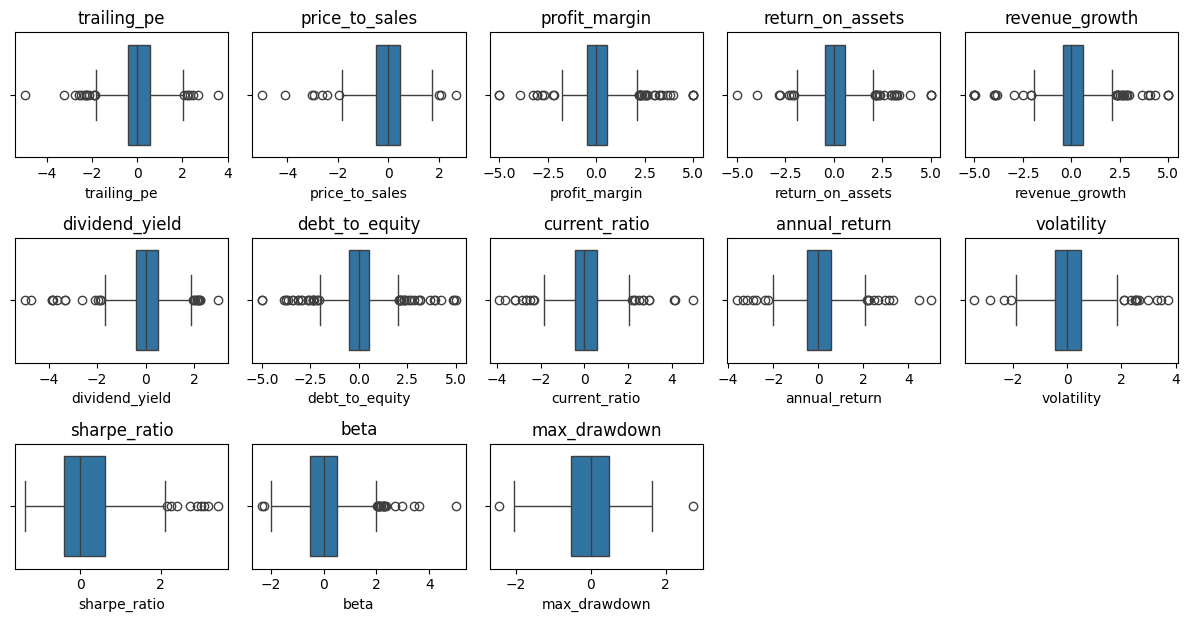

In [63]:
outlier_detection(X_clipped)

In [64]:
def correlation_heatmap(data, selected_features):
    corr_matrix = data[selected_features].corr(method='pearson')
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Pearson Correlation Heatmap")
    plt.show()

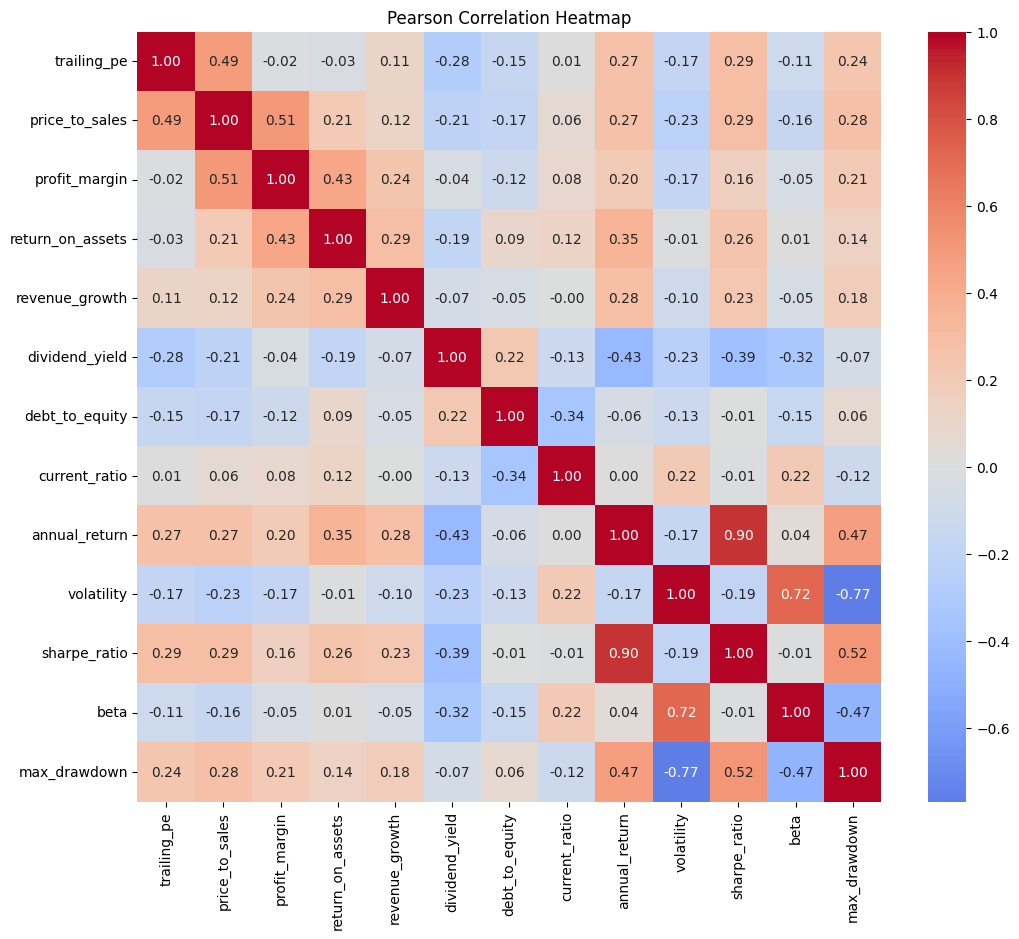

max_drawdown       0.5418
sharpe_ratio       0.6604
volatility         0.6879
price_to_sales     0.7065
dividend_yield     0.8044
beta               0.8128
trailing_pe        0.9467
annual_return      0.9553
current_ratio      0.9717
profit_margin      1.3174
debt_to_equity     1.5350
return_on_assets   1.5927
revenue_growth     2.0335
dtype: float64


In [65]:
# Droppinng features with high correlation
#_scaled_data_neutral = _scaled_data_neutral.drop(['sharpe_ratio', 'max_drawdown','sector'], axis=1)
correlation_heatmap(final_data, final_data.columns)
#_scaled_data_neutral = _scaled_data_neutral.drop(['sharpe_ratio', 'max_drawdown','sector'], axis=1)
vars = final_data.var()            # sample variance (ddof=1) by default
print(vars.sort_values())

## Clustering
> ### Factor buckets
> * 'Value': ['trailing_pe', 'price_to_sales'],
> * 'Growth': ['revenue_growth','return_on_assets'],
> * 'Quality': ['profit_margin','return_on_assets'],
> * 'Defensive': ['current_ratio','debt_to_equity'],
> * 'Risk_Momentum':  ['sharpe_ratio','max_drawdown']
> *


### K-Means in a Nutshell

1. **Goal** – partition observations into *k* clusters so that points are close to their own centroid and far from other centroids.  
2. **Algorithm**  
   * initialise *k* centroids (random or k-means++),  
   * assign each point to the nearest centroid (Euclidean distance on our scaled data),  
   * update each centroid to the mean of its assigned points,  
   * repeat assignment → update until centroids stop moving (convergence).  
3. **Why Euclidean distance works here** – after sector-neutral z-scaling, every feature is on the same numeric footing (“sector-IQR units”), so distance calculations treat each factor fairly.  
4. **Choosing *k*** – we combine three independent diagnostics:  
   * **Elbow (WCSS)** – find the bend where adding clusters yields diminishing WCSS improvement.  
   * **Silhouette score** – ranges –1 → +1; values > 0.3 already signal useful separation for noisy financial data.  
   * **Davies–Bouldin index** – lower is better; values < 1 are usually acceptable.  

In [66]:
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import scipy.cluster.hierarchy as sch


def Knn_cluster(data, k_num = 10):
    result_metric = {}


    for k in range(2, k_num+1):
        
        kmeans = KMeans(n_clusters=k,n_init=50, random_state=42).fit(data)
        sil_score = silhouette_score(data, kmeans.labels_, metric='euclidean')
        ch_score = calinski_harabasz_score(data, kmeans.labels_)
        db_score = davies_bouldin_score(data, kmeans.labels_) 
    
        result_metric[k] = {}
 
        result_metric[k]['silhouette_score'] = sil_score
        result_metric[k]['inertia'] = kmeans.inertia_
        result_metric[k]['score'] = kmeans.score
        result_metric[k]['model'] = kmeans
        result_metric[k]['ch_score'] = ch_score
        result_metric[k]['db_score'] = db_score

        #print(kmeans.labels_)
    return result_metric, kmeans


def hdbscan(data):
    cluster = HDBSCAN(min_cluster_size=15, min_samples=10,cluster_selection_method='leaf')
    labels = cluster.fit_predict(data) 
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    print(f"{n_clusters} clusters, {noise_frac:.1%} noise")
    #print("Persistence:", cluster.cluster_persistence_)   # array per cluster


    # Silhouette on core points
    #mask = labels >= 0
    #print("Silhouette (no-noise):",
    #silhouette_score(data[mask], labels[mask]))

def hierarchy(data):
    z = sch.linkage(data, method = 'ward', metric = 'euclidean')

    plt.figure(figsize=(10, 6))
    sch.dendrogram(z, truncate_mode='level', p=600)  
    # shows top 5 merges; remove truncate_mode to see all
    plt.xlabel('Stocks')
    plt.ylabel('Ward distance')
    plt.show()



In [67]:
from yellowbrick.cluster import SilhouetteVisualizer
def sil_visualizer(data, key, value, k_num = 2):
    metric, kmeans = Knn_cluster(data[value].copy(), k_num = k_num)
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
    visualizer.fit(data[value].copy())
    visualizer.poof()

In [ ]:
def plot_cluster_evaluation(ks, sil_score, key, wcss=None, ch_score=None,  db_score=None ):
    """
    Plots clustering evaluation metrics in a reusable way.

    Parameters:
    -----------
    ks : list or array-like
    sil_score : list or array-like
    key : str
        A title identifier that appears in the plot title.
    wcss : list or array-like, optional
        Within-Cluster Sum of Squares (WCSS)/elbow values to be plotted.
        (Set to None if you don’t have these, e.g., for HDBSCAN.)
    ch_score : list or array-like, optional
        Calinski–Harabasz scores. If provided, a third axis is added.
    
    The function creates:
      - Two y-axes if wcss is provided (left for WCSS in blue and right for silhouette in red),
        and a third axis if CH score is available.
      - A single axis for silhouette if wcss is None (for example, when evaluating HDBSCAN).
    """
    fig, ax1 = plt.subplots()

    # If WCSS data is available, plot it on the primary left axis.
    if wcss is not None:
        ax1.set_xlabel('Number of clusters (k)')
        ax1.set_ylabel('WCSS', color='tab:blue')
        line1, = ax1.plot(ks, wcss, marker='o', color='tab:blue', label='WCSS (elbow)')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        
        # Plot silhouette score on a secondary right axis.
        ax2 = ax1.twinx()                                       
        ax2.set_ylabel('Silhouette score', color='tab:red')
        line2, = ax2.plot(ks, sil_score, marker='s', linestyle='--', color='tab:red',
                          label='Silhouette')
        ax2.tick_params(axis='y', labelcolor='tab:red')
    else:
        # When no WCSS is provided (e.g. for HDBSCAN), plot silhouette on the primary axis.
        ax1.set_xlabel('Parameter values')
        ax1.set_ylabel('Silhouette score', color='tab:red')
        line2, = ax1.plot(ks, sil_score, marker='s', linestyle='--', color='tab:red',
                          label='Silhouette')
        ax1.tick_params(axis='y', labelcolor='tab:red')

    # Prepare legend handles.
    lines, labels = [], []
    if wcss is not None:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines.extend(lines1 + lines2)
        labels.extend(labels1 + labels2)
    else:
        lines, labels = ax1.get_legend_handles_labels()

    # Optionally plot Calinski–Harabasz if provided.
    if ch_score is not None:
        ax3 = ax1.twinx()
        # Move the third axis to avoid overlap with the second.
        ax3.spines['right'].set_position(('outward', 60))  
        ax3.set_ylabel('Calinski–Harabasz score', color='tab:green')
        line3, = ax3.plot(ks, ch_score, marker='^', linestyle='-.', color='tab:green',
                          label='CH Score')
        ax3.tick_params(axis='y', labelcolor='tab:green')
        lines.append(line3)
        labels.append('CH Score')
    
    # Combine legends from all active axes.
    ax1.legend(lines, labels, loc='best')
    
    if db_score is not None:
        ax4 = ax1.twinx()   
        ax4.spines['right'].set_position(('outward', 120))
        ax4.set_ylabel('Davies–Bouldin (lower better)', color='tab:purple')
        line4, = ax4.plot(ks, db_score, marker='v', linestyle=':',
                          color='tab:purple', label='DB')
        ax4.tick_params(axis='y', labelcolor='tab:purple')
        lines.append(line4)
        labels.append('DB')

    plt.title(f'Elbow vs. Silhouette vs. DB for {key}')
    plt.xticks(ks)
    plt.tight_layout()
    plt.show()

In [69]:
final_data

,trailing_pe,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,annual_return,volatility,sharpe_ratio,beta,max_drawdown
0,-0.4345,0.0621,0.4553,-0.2431,-0.2308,0.9142,1.9083,0.1378,-0.0508,0.3874,-0.1410,-0.6667,-0.6645
1,-0.5822,-0.1954,0.1236,0.9407,-1.0895,0.4889,-2.0598,0.3240,-0.3151,0.0000,-0.3877,-0.3784,-0.2415
2,-0.6160,0.3847,1.5858,0.0000,-0.2348,0.5874,-0.8885,0.0000,0.7043,-0.9371,0.8261,-0.2432,0.6822
3,1.1980,0.3972,-0.1494,0.7687,-0.0259,1.2948,3.8902,-1.3860,0.7634,-0.7134,0.8913,-0.8378,1.0521
4,-0.2698,-0.5847,-0.4470,0.6028,-0.3249,0.6364,-0.4144,0.0871,-0.4816,-0.6763,-0.6386,-0.4494,0.5424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.4352,0.1082,-0.2646,-0.5634,0.4273,-0.0391,-1.3997,0.5588,0.1971,-0.2213,0.1762,0.0901,0.1737
497,0.6709,1.0144,1.4477,1.4042,1.0903,0.2902,0.0000,0.1992,0.1227,-1.5190,0.2342,-1.0602,1.5289
498,-0.3410,-0.6865,-0.5177,-0.1404,1.5615,-0.4037,0.2238,0.0502,-1.4211,0.3893,-1.0964,0.5169,-0.5721
499,-0.2318,-0.1299,0.1332,-0.3128,-0.1954,0.2080,-0.3552,0.5329,-0.1395,-0.6092,-0.2391,0.1622,0.2542


Value ['trailing_pe', 'price_to_sales']


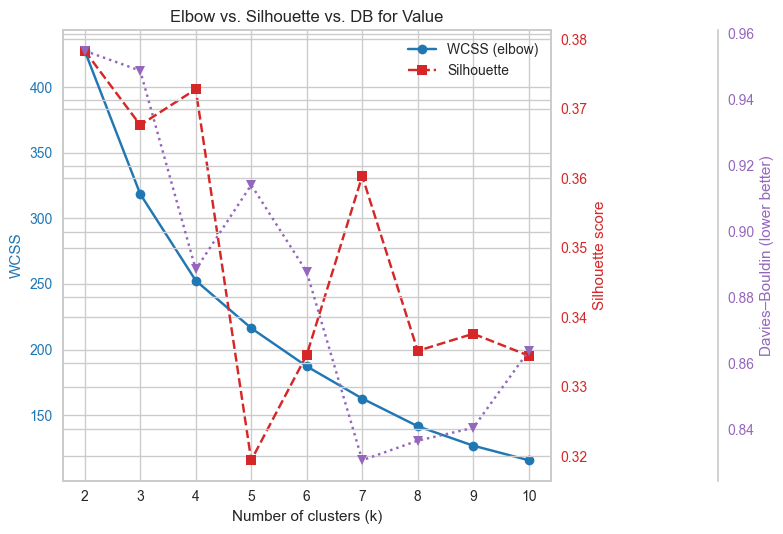

Growth ['revenue_growth', 'return_on_assets']


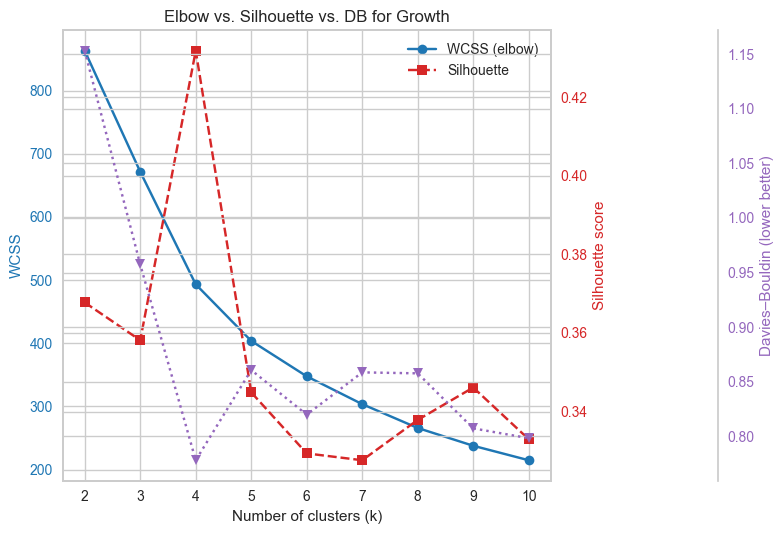

Quality ['profit_margin', 'return_on_assets']


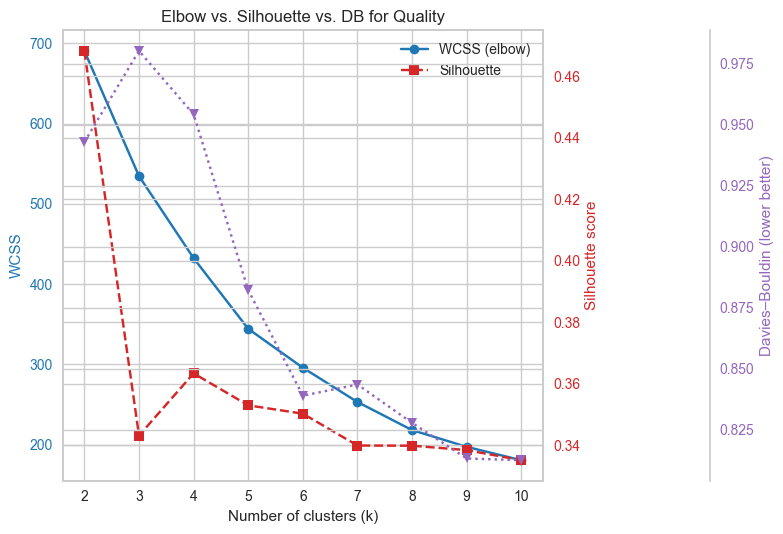

Defensive ['current_ratio', 'debt_to_equity']


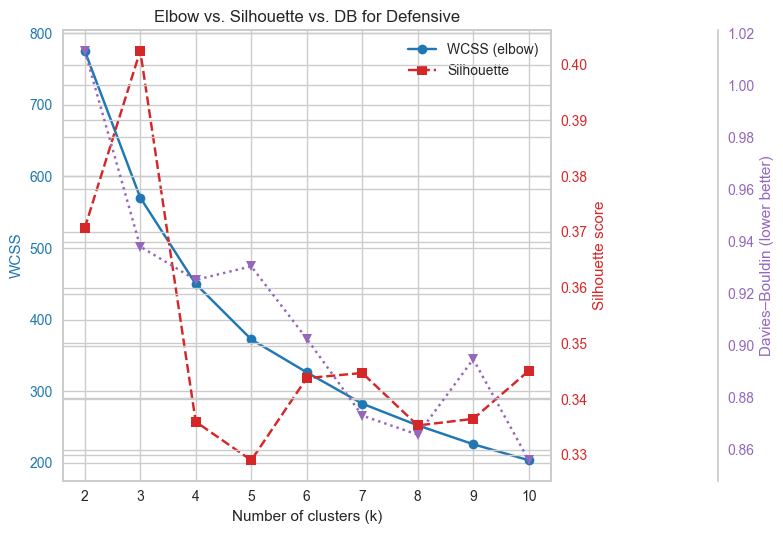

Risk_Momentum ['sharpe_ratio', 'max_drawdown']


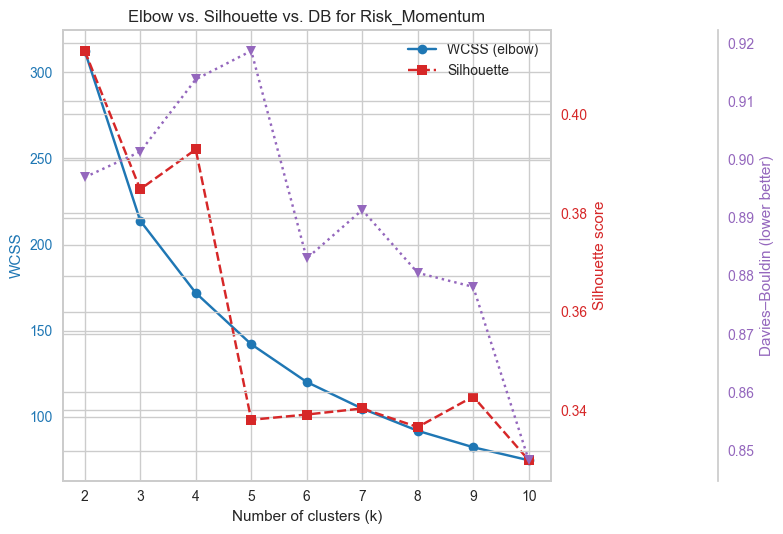

In [70]:
bucket = {
    'Value': ['trailing_pe', 'price_to_sales'],
    'Growth': ['revenue_growth','return_on_assets'],
    'Quality': ['profit_margin','return_on_assets'],
    'Defensive': ['current_ratio','debt_to_equity'],
    'Risk_Momentum':  ['sharpe_ratio','max_drawdown']
}

k_means_obj = {}

for key, value in bucket.items():
    print(key, value)   
    metric, kmeans = Knn_cluster(X_clipped[value].copy(), k_num = 10)
    #hdbscan(final_data[value])
    k_means_obj[key] = kmeans   
    ks        = sorted(metric.keys())
    wcss      = [metric[k]['inertia']     for k in ks]
    sil_score = [metric[k]['silhouette_score']  for k in ks]
    ch_score =  [metric[k]['ch_score'] for k in ks]
    db_score = [metric[k]['db_score'] for k in ks]
    

    plot_cluster_evaluation(ks=ks, wcss= wcss, sil_score= sil_score, key= key, db_score= db_score)
    

Based on the Silhouette Score and Elbow  values of K in the range of 2-4 is optimal
Optimal cluster - 3

### Chosen *k* for Each Factor Family

| Factor bucket | k | Why this k? — visual cues from the “Elbow - Silhouette - Davies-Bouldin” chart |
|---------------|---|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Value** | **4** | WCSS elbow at k = 4, Silhouette local high ≈ 0.37, DB trough ≈ 0.89, and bootstrap ARI 0.81 ± 0.13 validates four clusters give the best mix of separation and stability. |
| **Growth** | **2** | Internal metrics favour k ≈ 4 (Silhouette peak ≈ 0.43, DB trough ≈ 0.79), yet bootstrap stability is weaker (median ARI ≈ 0.58 ) and the four-way split offers no clear factor story. We therefore keep the simpler, more reproducible two-cluster solution.|
| **Quality** | **3** | Internal metrics favour k ≈ 3 (Silhouette local high ≈ 0.38, DB dip ≈ 0.86). Bootstrap ARI is bimodal—median ≈ 0.79 but a left-tail down to 0.2—so clusters are solid in most resamples yet occasionally reshuffle. We keep k = 3 as the best trade-off between cohesion and acceptable stability. |
 **Defensive** | **3** | WCSS elbow at k = 3, Silhouette bump ≈ 0.40, DB dip ≈ 0.87; bootstrap ARI 0.87 ± 0.18 (most runs > 0.75) → three clusters balance cohesion with solid repeatability. |
| **Risk & Momentum** | **3** | WCSS bend near k = 3, Silhouette plateau ≈ 0.34, DB trough ≈ 0.86; bootstrap ARI 0.94 ± 0.08 — clusters are exceptionally stable, so k = 3 is the clear choice. |

In [142]:
k_value = { 'Value': 4, 'Growth': 2, 'Quality': 3, 'Defensive': 3, 'Risk_Momentum': 3 }

#for key, value in bucket.items(): 
#    sil_visualizer(X_clipped, key, value, k_num= k_value[key])

In [72]:
def final_label_centroid(data,value, k_num = 2):
    kmeans = KMeans(n_clusters= k_num,n_init=50, random_state=42).fit(data[value].copy())
    labels = kmeans.labels_
    centroid = kmeans.cluster_centers_

    return labels, centroid , kmeans
    

In [73]:
# Optimal k value 3 for each bucket
labels = {}
centroid = {}
kmeans = {}
for key, value in bucket.items():
    print(key, value)
    labels_, centroid_, kmeans_ = final_label_centroid(X_clipped,value, k_num = k_value[key])
    labels[key] = labels_
    centroid[key] = centroid_
    kmeans[key] = kmeans_
    #print(labels[key])
    

Value ['trailing_pe', 'price_to_sales']
Growth ['revenue_growth', 'return_on_assets']
Quality ['profit_margin', 'return_on_assets']
Defensive ['current_ratio', 'debt_to_equity']
Risk_Momentum ['sharpe_ratio', 'max_drawdown']


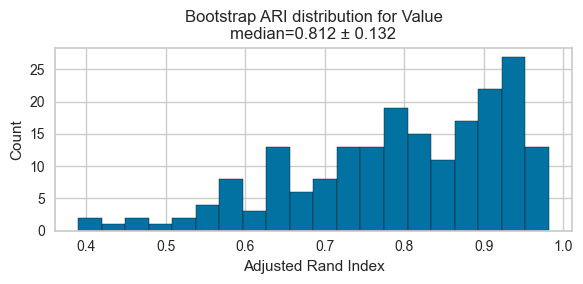

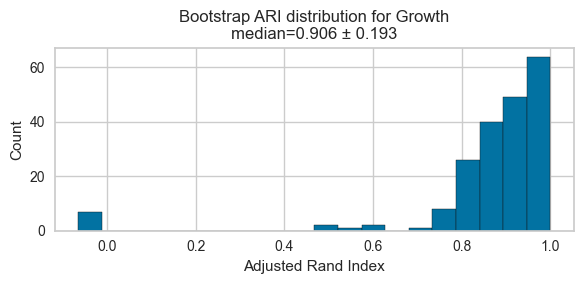

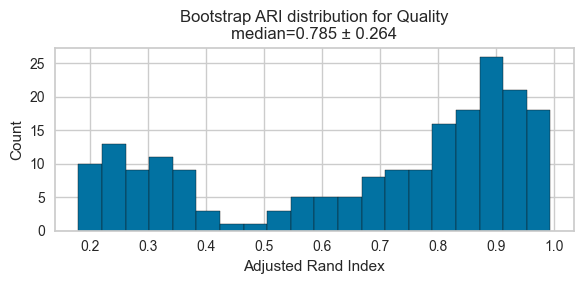

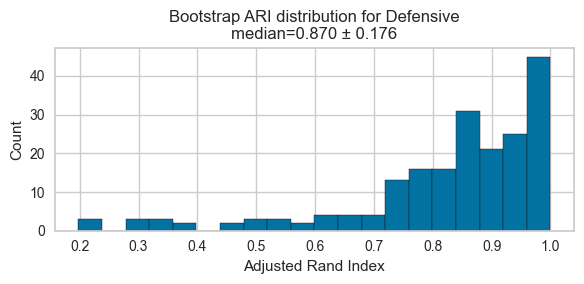

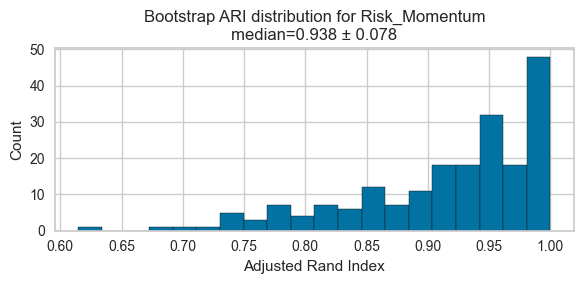

In [141]:
# Cluster Roboustness
from sklearn.metrics import adjusted_rand_score
results = {}
# assuming my final_data.index as stock id

for key, value in bucket.items():
    aris = []
    base_labels = pd.Series(labels[key], index=X_clipped.index, name = 'baseline_labels')
    for b in range(200):
        sample = X_clipped[value].sample(frac=1, replace=True, random_state=b)
        km = KMeans(n_clusters= k_value[key] ,n_init=50, random_state=42).fit(sample)
        label_b = km.labels_
        #print(label_b)
        
        ari = adjusted_rand_score(base_labels.loc[sample.index], label_b)
        aris.append(ari)
        
    results[key] = {
        'Ari_mean': np.mean(aris),
        'Ari_std': np.std(aris),
        'Ari_median': np.median(aris)
    }
     # 4) Quick histogram of ARI
    plt.figure(figsize=(6,3))
    plt.hist(aris, bins=20, edgecolor='k')
    plt.title(f'Bootstrap ARI distribution for {key}\n'
            f'median={results[key]["Ari_median"]:.3f} ± {results[key]["Ari_std"]:.3f}')

    plt.xlabel('Adjusted Rand Index')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    
    

### Centroids for each buckets

#### Value centroids
| Cluster |  trailing_pe | price_to_sales |
|---------|-----:|-----:|
| 0 |  1.033 |  0.777 |
| 1 | –0.013 | –1.142 |
| 2 | –1.459 | –0.772 |
| 3 | –0.057 |  0.094 |

#### Growth centroids
| Cluster |   revenue_growth | return on assets |
|---------|-----:|-----:|
| 0 | –0.375 | –0.265 |
| 1 |  1.012 |  0.900 |

#### Quality centroids
| Cluster |  profit_margin | return on assets |
|---------|-----:|-----:|
| 0 | –0.856 | –0.705 |
| 1 |  1.638 |  1.595 |
| 2 |  0.210 |  0.145 |

#### Defensive centroids
| Cluster | current_ratio | debt_to_equity |
|---------|-----:|-----:|
| 0 | –0.152 |  0.038 |
| 1 | –0.433 |  1.935 |
| 2 |  1.172 | –1.504 |

#### Risk & Momentum centroids
| Cluster | sharpe_ratio | max_drawdown|
|---------|-----:|-----:|
| 0 |  1.336 |  0.649 |
| 1 | –0.506 | –0.799 |
| 2 |  0.082 |  0.233 |


In [75]:
centroid

{'Value': array([[ 1.03279717,  0.77717424],
        [-0.01319875, -1.14199491],
        [-1.45881156, -0.77201492],
        [-0.05650853,  0.09350058]]),
 'Growth': array([[-0.37462502, -0.26507795],
        [ 1.01154503,  0.90015426]]),
 'Quality': array([[-0.85597984, -0.70507551],
        [ 1.63783575,  1.59459192],
        [ 0.21039404,  0.14464935]]),
 'Defensive': array([[-0.15163399,  0.03786865],
        [-0.4325758 ,  1.93538934],
        [ 1.17230251, -1.50362961]]),
 'Risk_Momentum': array([[ 1.33565038,  0.64881495],
        [-0.50554277, -0.79946503],
        [ 0.08240124,  0.23349417]])}

In [76]:
for key, value in bucket.items():
    X_clipped[key] = labels[key]
    clean_data[key] = labels[key]


In [77]:
for key, value in bucket.items():
    print(clean_data[[value[0],value[1],f'{key}']].groupby(f'{key}').median())

       trailing_pe  price_to_sales
Value                             
0          39.2987          6.5069
1          20.3251          0.9304
2          11.6358          1.0848
3          21.4096          3.2107
        revenue_growth  return_on_assets
Growth                                  
0               0.0250            0.0445
1               0.1300            0.0858
         profit_margin  return_on_assets
Quality                                 
0               0.0471            0.0290
1               0.2781            0.1331
2               0.1439            0.0637
           current_ratio  debt_to_equity
Defensive                               
0                 1.1285         75.6290
1                 1.0065        310.5695
2                 2.4345         19.6930
               sharpe_ratio  max_drawdown
Risk_Momentum                            
0                    0.5900       -0.2500
1                   -0.3100       -0.5000
2                    0.0200       -0.3200


In [78]:
clean_data['ticker'] = merged_df['ticker']

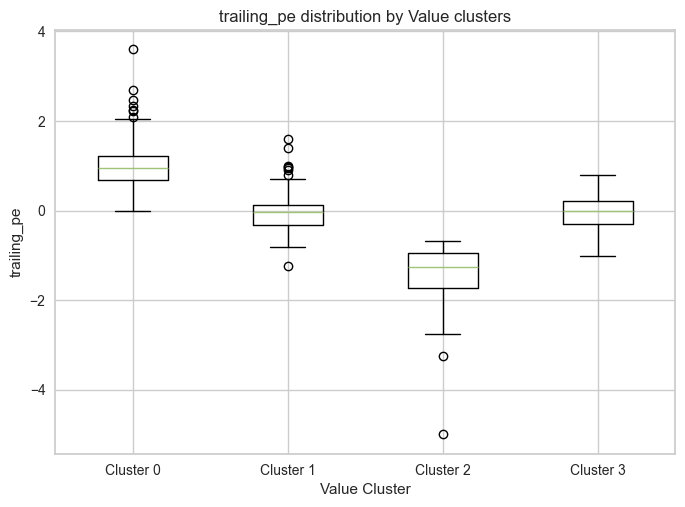

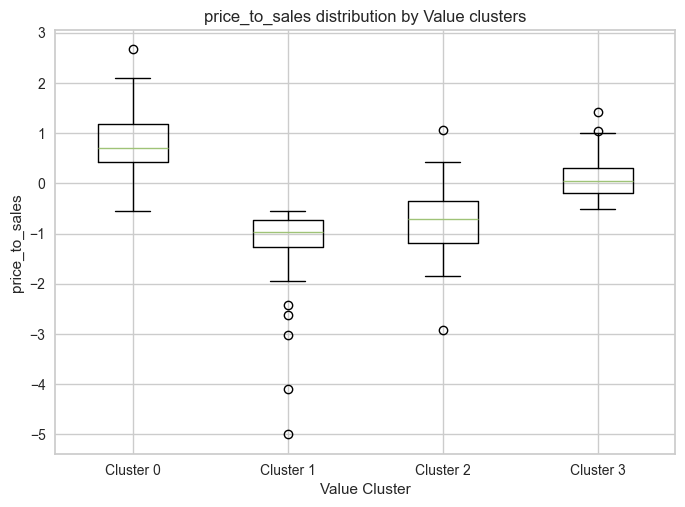

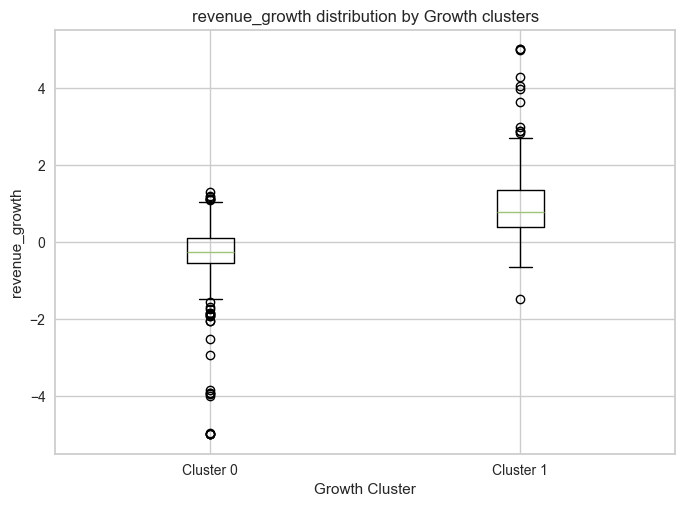

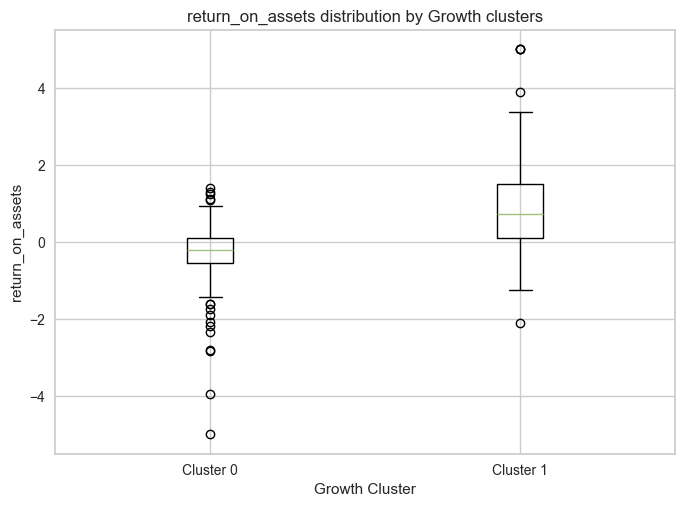

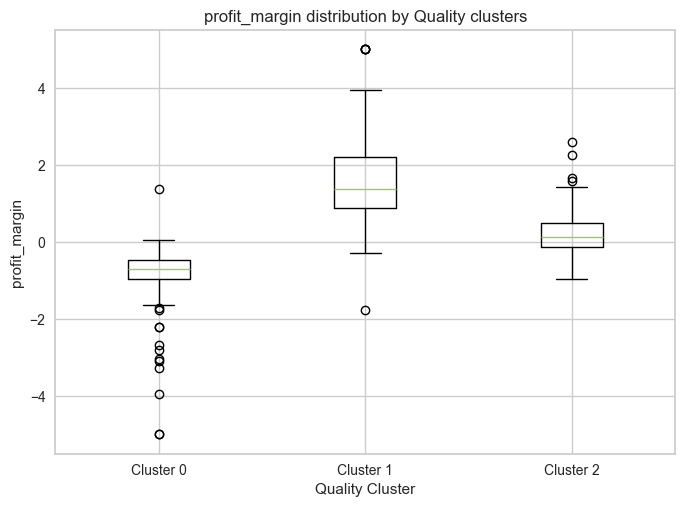

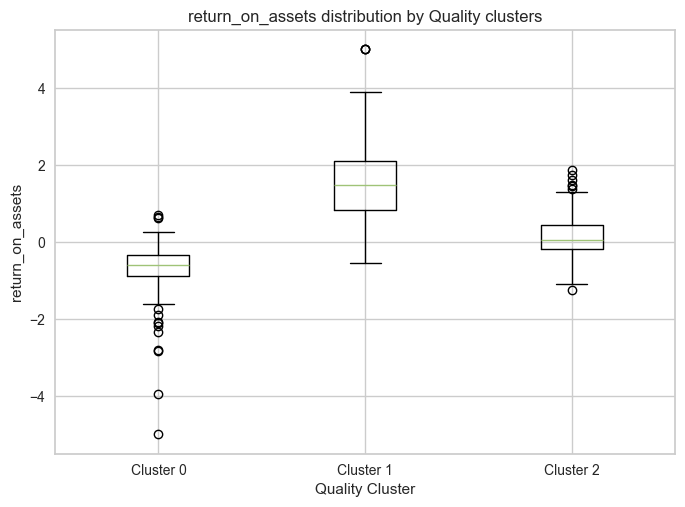

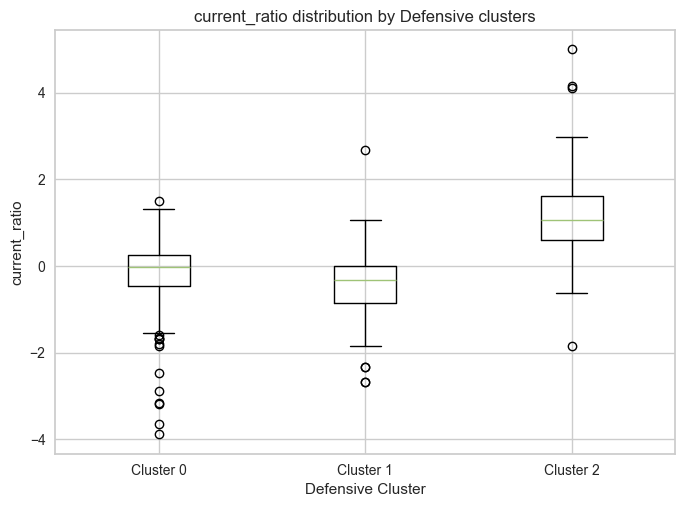

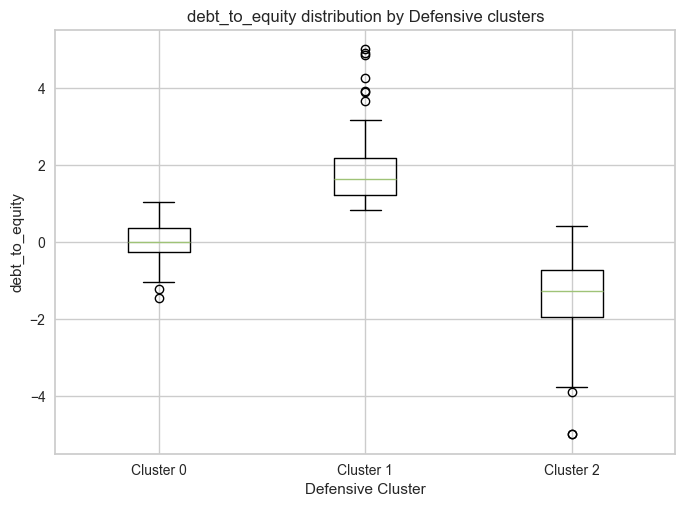

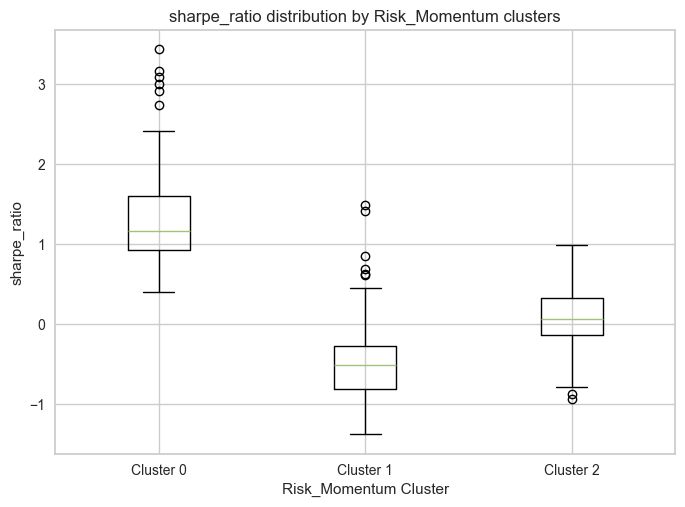

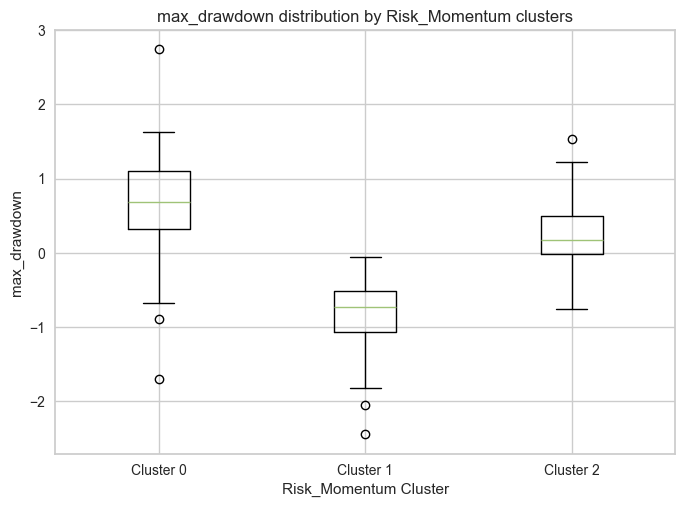

In [79]:
# Box plot 
for theme, feats in bucket.items():
    for feat in feats:
        # Prepare the data for boxplot: list of arrays, one per cluster label
        data = X_clipped[[feat, theme]].dropna()
        cluster_labels = sorted(data[theme].unique())
        groups = [data[data[theme] == label][feat].values for label in cluster_labels]
        
        # Plot
        plt.figure()
        plt.boxplot(groups, tick_labels=[f"Cluster {l}" for l in cluster_labels])
        plt.title(f"{feat} distribution by {theme} clusters")
        plt.xlabel(f"{theme} Cluster")
        plt.ylabel(feat)
        plt.show()

## Based on Cluster Value see the Labels below

In [80]:
bucket_label_map = {
    'Value': {
        0: 'Overvalued',    # High P/E & P/S
        1: 'Undervalued',   # P/S-only & Deep combined
        2: 'Undervalued',
        3: 'Fair Value'
    },
    'Growth': {
        0: 'Low Growth',
        1: 'High Growth'
    },
    'Quality': {
        0: 'Low Quality',
        2: 'Average Quality',
        1: 'High Quality'
    },
    'Defensive': {
        0: 'Average Defense',
        1: 'Low Defense',
        2: 'High Defense'
    },
    'Risk_Momentum': {
        0: 'High Momentum',
        2: 'Average Momentum',
        1: 'Low Momentum'
    }
}

> * Note : Our Value groups are built relative to each stock’s sector. We first neutralize P/E and P/S by subtracting the sector median and scaling by the IQR, so a z-score below zero means “cheaper  than your sector peers.” For example, Accenture (ACN) has z-scores of –0.27 on P/E and –0.58 on P/S—making it “Undervalued” in the Technology bucket—even though its raw P/E (~23×) is near the market median.

If you prefer an absolute/global view, we also provide a “Fair Value” label based on distance to the real-unit centroids across the whole universe.

In [81]:
for key, value in bucket.items():
    clean_data[f'{key}'] = clean_data[f'{key}'].map(bucket_label_map[key])
    X_clipped[f'{key}'] = X_clipped[f'{key}'].map(bucket_label_map[key])
    

## CLuster Plots

In [144]:
def _final_kmeans_plot(data, key, value,bucket_label_map, k_num = 2):
    kmeans = KMeans(n_clusters= k_num,n_init=50, random_state=42).fit(data[value].copy())
    labels = kmeans.labels_
    centroid = kmeans.cluster_centers_

    # Scatter plot in z-space
    plt.figure(figsize=(7,7))
    scat = plt.scatter(
       x = data[value[0]], y = data[value[1]],
        c=labels, cmap='tab10', s=50, alpha=0.7, edgecolor='k'
    )
    handles, _ = scat.legend_elements()
    plt.legend(handles, [str(i) for i in range(k_num)],
               title="Cluster ID", loc="best")
    
    # Plot centroids
    cent = plt.scatter(
        centroid[:,0], centroid[:,1],
     c='black', s=200, marker='X', label='Centroids'
    )

    names = [bucket_label_map[key][i] for i in range(k_num)]
    labels_list = names + ['Centroids']
    handles_list = list(handles) + [cent]

   
    cent_handle, _ = cent.legend_elements()
    plt.xlabel(f'{value[0]} (z)')    
    plt.ylabel(f'{value[1]} (z)')    
    plt.title('Clusters in Z-Space')
    plt.legend(handles_list, labels_list, loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    return labels, centroid

Value ['trailing_pe', 'price_to_sales']


d:\AI_portfolio_Screener\venv\Lib\site-packages\matplotlib\collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


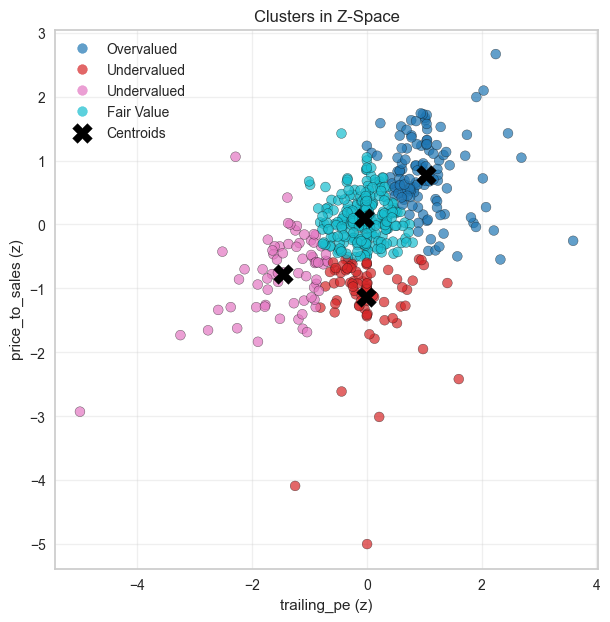

Growth ['revenue_growth', 'return_on_assets']


d:\AI_portfolio_Screener\venv\Lib\site-packages\matplotlib\collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


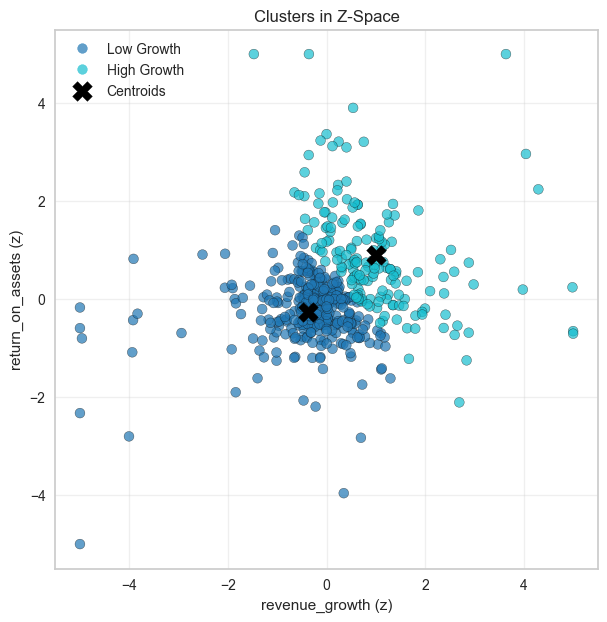

Quality ['profit_margin', 'return_on_assets']


d:\AI_portfolio_Screener\venv\Lib\site-packages\matplotlib\collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


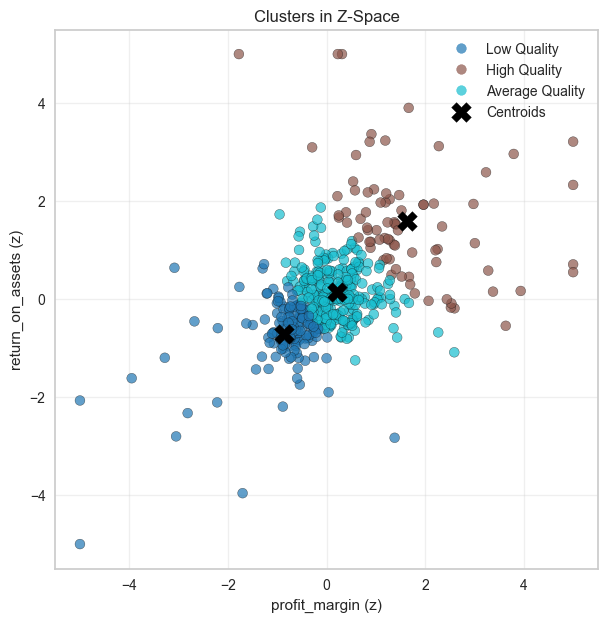

Defensive ['current_ratio', 'debt_to_equity']


d:\AI_portfolio_Screener\venv\Lib\site-packages\matplotlib\collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


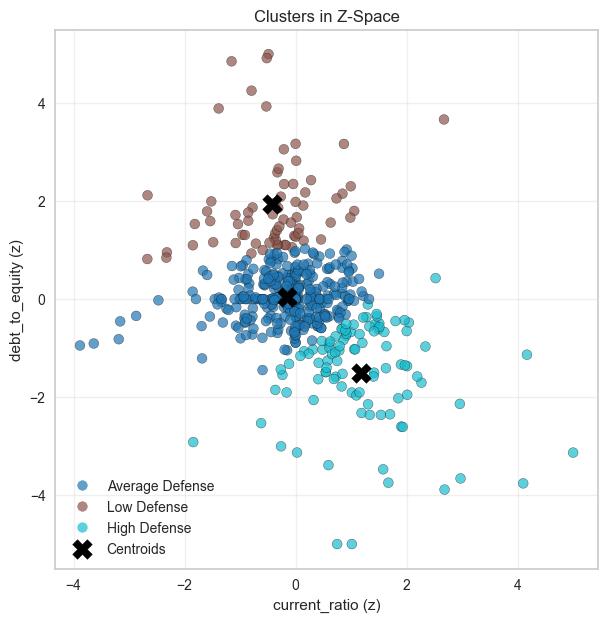

Risk_Momentum ['sharpe_ratio', 'max_drawdown']


d:\AI_portfolio_Screener\venv\Lib\site-packages\matplotlib\collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


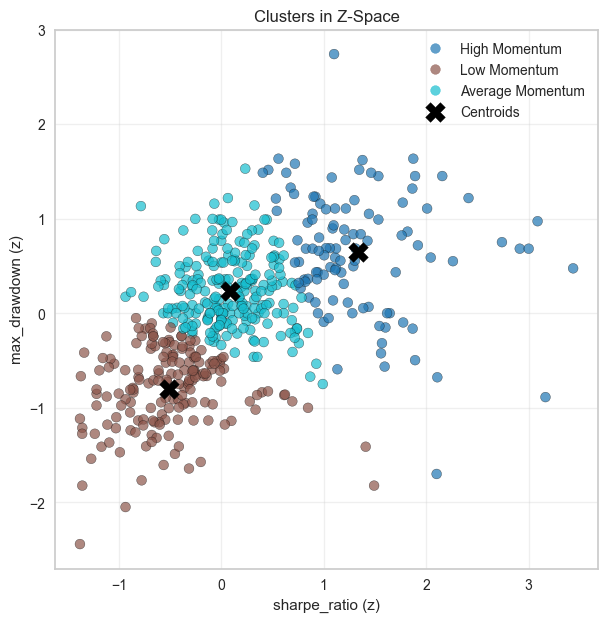

In [145]:
for key, value in bucket.items():
    print(key, value)
    labels_, centroid_= _final_kmeans_plot(X_clipped, key, value, bucket_label_map, k_num = k_value[key])

##  Portfolio Back-Test


### 3.1 Test setup  

| Item | Choice | Rationale |
|------|--------|-----------|
| **Universe** | Current S&P 500 constituents | Matches the clustering sample. |
| **Price data** | Adjusted daily closes from `yfinance` | Consistent, dividend-adjusted. |
| **Forward_Sanity_test**| 7 week test | Lacking fundamental data for backtest
---

### 3.2 Strategy definitions  

| Strategy name | Cluster rule | Intuitive story |
|---------------|--------------|-----------------|
| **Value-Seeker** | Hold stocks in the **“Undervalued”** cluster(s) of the Value bucket (e.g. clusters 0 & 1 where P/E and P/S are lowest). | Classic bargain hunting: buy the cheapest quartile and ignore the rest. |
| **Growth-Chaser** | Hold stocks in the **“High-Growth”** cluster of the Growth bucket (cluster 1 in our k = 2 split). | Bet that firms with double-digit revenue growth and high ROA will keep re-rating upward. |
| **Composite** | Intersection of three “top” clusters:<br> · Growth = High Growth (cluster 1)<br> · Risk/Momentum = High Sharpe / low draw-down (cluster 0)<br> · Quality = High Margin & ROA (cluster 1) | Concentrated sleeve that demands **growth + momentum + quality** in one package. Think of it as a “best-of-everything” basket. |



In [84]:
clean_data

,trailing_pe,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_equity,return_on_assets,revenue_growth,eps_growth,dividend_yield,...,sharpe_ratio,beta,max_drawdown,sector,Value,Growth,Quality,Defensive,Risk_Momentum,ticker
0,18.6873,17.1734,19.0494,3.0747,0.1698,0.9185,0.0593,0.0010,-0.2300,0.0286,...,0.0700,0.8000,-0.4000,Industrials,Fair Value,Low Growth,Average Quality,Low Defense,Low Momentum,MMM
1,17.3650,15.4877,4.8299,2.4245,0.1398,0.2863,0.1353,-0.0770,-0.2010,0.0211,...,-0.0700,0.8800,-0.3400,Industrials,Fair Value,Low Growth,Average Quality,High Defense,Low Momentum,AOS
2,17.2094,25.4806,4.7769,5.4303,0.3189,0.1285,0.0568,0.0400,0.0820,0.0176,...,0.0700,0.6100,-0.2500,Healthcare,Fair Value,Low Growth,Average Quality,Average Defense,High Momentum,ABT
3,72.8015,14.2842,91.9679,5.5314,0.0759,0.6229,0.0849,0.0560,NaN,0.0370,...,0.1000,0.3900,-0.2000,Healthcare,Overvalued,High Growth,Average Quality,Low Defense,High Momentum,ABBV
4,23.3515,20.1151,6.0622,2.6652,0.1143,0.2697,0.1158,0.0540,0.0680,0.0205,...,-0.2100,1.0400,-0.2900,Technology,Undervalued,Low Growth,Average Quality,Average Defense,Average Momentum,ACN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,30.3795,23.3442,2.5318,3.2068,0.1040,0.0845,0.0430,0.0650,0.2260,0.0133,...,0.2500,1.0100,-0.2900,Industrials,Fair Value,Low Growth,Low Quality,High Defense,Average Momentum,XYL
497,27.4761,23.6349,-5.2422,5.4074,0.1968,0.3169,0.2449,0.1600,-0.0860,0.0194,...,0.1200,0.6400,-0.1800,Consumer Cyclical,Overvalued,High Growth,High Quality,Average Defense,Average Momentum,YUM
498,22.1475,14.0424,3.2351,2.3645,0.1060,0.1595,0.0626,0.3220,8.5880,0.0000,...,-0.4000,1.4700,-0.5100,Technology,Undervalued,High Growth,Low Quality,Average Defense,Low Momentum,ZBRA
499,21.8335,11.2468,1.5445,2.5374,0.1177,0.0725,0.0465,0.0430,-0.4290,0.0100,...,-0.4200,0.7600,-0.3200,Healthcare,Fair Value,Low Growth,Average Quality,Average Defense,Average Momentum,ZBH


In [85]:
mask = X_clipped[X_clipped['Value'] == 'Fair Value'].copy()
cent_under = mask[bucket['Value']].mean().values
display(mask)
#cent_under

,trailing_pe,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,annual_return,volatility,sharpe_ratio,beta,max_drawdown,Value,Growth,Quality,Defensive,Risk_Momentum
0,-0.4345,0.0621,0.4553,-0.2431,-0.2308,0.9142,1.9083,0.1378,-0.0508,0.3874,-0.1410,-0.6667,-0.6645,Fair Value,Low Growth,Average Quality,Low Defense,Low Momentum
1,-0.5822,-0.1954,0.1236,0.9407,-1.0895,0.4889,-2.0598,0.3240,-0.3151,0.0000,-0.3877,-0.3784,-0.2415,Fair Value,Low Growth,Average Quality,High Defense,Low Momentum
2,-0.6160,0.3847,1.5858,0.0000,-0.2348,0.5874,-0.8885,0.0000,0.7043,-0.9371,0.8261,-0.2432,0.6822,Fair Value,Low Growth,Average Quality,Average Defense,High Momentum
5,-0.2910,0.2343,1.2792,1.2010,0.0530,-0.4037,0.0267,-0.1786,-0.7150,0.1486,-0.6867,0.1348,-0.3760,Fair Value,High Growth,High Quality,Average Defense,Low Momentum
8,-0.2090,0.0954,0.5214,0.2993,2.9825,0.0675,-0.4981,1.5074,0.8835,-0.7932,1.2000,-0.6374,0.8851,Fair Value,High Growth,Average Quality,High Defense,High Momentum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,-0.1659,-0.4282,-0.3569,-0.3463,-0.3504,0.0533,0.0000,0.5924,-0.1276,0.4182,-0.1081,0.6265,-0.2093,Fair Value,Low Growth,Low Quality,Average Defense,Average Momentum
495,-0.2415,0.0941,0.0418,-1.9010,-1.8417,0.0460,-0.0972,-0.1322,-0.4436,0.1722,-0.4068,-0.3590,-0.5226,Fair Value,Low Growth,Low Quality,Average Defense,Low Momentum
496,0.4352,0.1082,-0.2646,-0.5634,0.4273,-0.0391,-1.3997,0.5588,0.1971,-0.2213,0.1762,0.0901,0.1737,Fair Value,Low Growth,Low Quality,High Defense,Average Momentum
499,-0.2318,-0.1299,0.1332,-0.3128,-0.1954,0.2080,-0.3552,0.5329,-0.1395,-0.6092,-0.2391,0.1622,0.2542,Fair Value,Low Growth,Average Quality,Average Defense,Average Momentum


In [86]:
def centroid_distance(df, key, feature, label):
        mask_= df[df[key] == label]
        centroid_ = mask_[feature].mean().values
        #display(mask_)
        #print(centroid_)
        #print(mask_[feature].values - centroid_)
        dis = np.linalg.norm(mask_[feature].values - centroid_, axis=1)  
        return dis

In [87]:
ranked_data = X_clipped.copy()
ranked_data['stock_id'] = merged_df['stock_id']

In [88]:
for key, feature in bucket.items():
    dist_col = f'{key}_distance'
    ranked_data[dist_col] = np.nan
    for label in X_clipped[key].unique():
        mask = ranked_data[key] == label
        #display(test_data)
        distance = centroid_distance(ranked_data, key, feature, label)
        ranked_data.loc[mask, dist_col] = distance  


In [89]:
display(ranked_data)

,trailing_pe,price_to_sales,profit_margin,return_on_assets,revenue_growth,dividend_yield,debt_to_equity,current_ratio,annual_return,volatility,...,Growth,Quality,Defensive,Risk_Momentum,stock_id,Value_distance,Growth_distance,Quality_distance,Defensive_distance,Risk_Momentum_distance
0,-0.4345,0.0621,0.4553,-0.2431,-0.2308,0.9142,1.9083,0.1378,-0.0508,0.3874,...,Low Growth,Average Quality,Low Defense,Low Momentum,910000,0.3793,0.1455,0.4586,0.5710,0.3888
1,-0.5822,-0.1954,0.1236,0.9407,-1.0895,0.4889,-2.0598,0.3240,-0.3151,0.0000,...,Low Growth,Average Quality,High Defense,Low Momentum,910001,0.5998,1.4018,0.8008,1.0143,0.5703
2,-0.6160,0.3847,1.5858,0.0000,-0.2348,0.5874,-0.8885,0.0000,0.7043,-0.9371,...,Low Growth,Average Quality,Average Defense,High Momentum,910002,0.6307,0.2997,1.3830,0.9387,0.5107
3,1.1980,0.3972,-0.1494,0.7687,-0.0259,1.2948,3.8902,-1.3860,0.7634,-0.7134,...,High Growth,Average Quality,Low Defense,High Momentum,910003,0.4143,1.0457,0.7203,2.1749,0.6001
4,-0.2698,-0.5847,-0.4470,0.6028,-0.3249,0.6364,-0.4144,0.0871,-0.4816,-0.6763,...,Low Growth,Average Quality,Average Defense,Average Momentum,910004,0.5703,0.8693,0.8013,0.5114,0.7844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.4352,0.1082,-0.2646,-0.5634,0.4273,-0.0391,-1.3997,0.5588,0.1971,-0.2213,...,Low Growth,Low Quality,High Defense,Average Momentum,910498,0.4919,0.8556,0.6081,0.6223,0.1112
497,0.6709,1.0144,1.4477,1.4042,1.0903,0.2902,0.0000,0.1992,0.1227,-1.5190,...,High Growth,High Quality,Average Defense,Average Momentum,910499,0.4327,0.5101,0.2691,0.3528,1.3043
498,-0.3410,-0.6865,-0.5177,-0.1404,1.5615,-0.4037,0.2238,0.0502,-1.4211,0.3893,...,High Growth,Low Quality,Average Defense,Low Momentum,910500,0.4500,1.1770,0.6582,0.2744,0.6331
499,-0.2318,-0.1299,0.1332,-0.3128,-0.1954,0.2080,-0.3552,0.5329,-0.1395,-0.6092,...,Low Growth,Average Quality,Average Defense,Average Momentum,910501,0.2840,0.1855,0.4639,0.7894,0.3222


In [90]:
clean_data['stock_id'] = merged_df['stock_id']

In [91]:
clean_data = clean_data.merge(ranked_data[['stock_id','Value_distance','Growth_distance','Quality_distance','Defensive_distance','Risk_Momentum_distance']], how='left', on='stock_id')


In [92]:
clean_data

,trailing_pe,forward_pe,price_to_book,price_to_sales,profit_margin,return_on_equity,return_on_assets,revenue_growth,eps_growth,dividend_yield,...,Quality,Defensive,Risk_Momentum,ticker,stock_id,Value_distance,Growth_distance,Quality_distance,Defensive_distance,Risk_Momentum_distance
0,18.6873,17.1734,19.0494,3.0747,0.1698,0.9185,0.0593,0.0010,-0.2300,0.0286,...,Average Quality,Low Defense,Low Momentum,MMM,910000,0.3793,0.1455,0.4586,0.5710,0.3888
1,17.3650,15.4877,4.8299,2.4245,0.1398,0.2863,0.1353,-0.0770,-0.2010,0.0211,...,Average Quality,High Defense,Low Momentum,AOS,910001,0.5998,1.4018,0.8008,1.0143,0.5703
2,17.2094,25.4806,4.7769,5.4303,0.3189,0.1285,0.0568,0.0400,0.0820,0.0176,...,Average Quality,Average Defense,High Momentum,ABT,910002,0.6307,0.2997,1.3830,0.9387,0.5107
3,72.8015,14.2842,91.9679,5.5314,0.0759,0.6229,0.0849,0.0560,NaN,0.0370,...,Average Quality,Low Defense,High Momentum,ABBV,910003,0.4143,1.0457,0.7203,2.1749,0.6001
4,23.3515,20.1151,6.0622,2.6652,0.1143,0.2697,0.1158,0.0540,0.0680,0.0205,...,Average Quality,Average Defense,Average Momentum,ACN,910004,0.5703,0.8693,0.8013,0.5114,0.7844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,30.3795,23.3442,2.5318,3.2068,0.1040,0.0845,0.0430,0.0650,0.2260,0.0133,...,Low Quality,High Defense,Average Momentum,XYL,910498,0.4919,0.8556,0.6081,0.6223,0.1112
497,27.4761,23.6349,-5.2422,5.4074,0.1968,0.3169,0.2449,0.1600,-0.0860,0.0194,...,High Quality,Average Defense,Average Momentum,YUM,910499,0.4327,0.5101,0.2691,0.3528,1.3043
498,22.1475,14.0424,3.2351,2.3645,0.1060,0.1595,0.0626,0.3220,8.5880,0.0000,...,Low Quality,Average Defense,Low Momentum,ZBRA,910500,0.4500,1.1770,0.6582,0.2744,0.6331
499,21.8335,11.2468,1.5445,2.5374,0.1177,0.0725,0.0465,0.0430,-0.4290,0.0100,...,Average Quality,Average Defense,Average Momentum,ZBH,910501,0.2840,0.1855,0.4639,0.7894,0.3222


In [93]:
data_to_save = clean_data[['stock_id','sector','ticker','Value','Growth','Quality','Defensive','Risk_Momentum','sharpe_ratio','beta','Value_distance','Growth_distance','Quality_distance','Defensive_distance','Risk_Momentum_distance']]
data_to_save

,stock_id,sector,ticker,Value,Growth,Quality,Defensive,Risk_Momentum,sharpe_ratio,beta,Value_distance,Growth_distance,Quality_distance,Defensive_distance,Risk_Momentum_distance
0,910000,Industrials,MMM,Fair Value,Low Growth,Average Quality,Low Defense,Low Momentum,0.0700,0.8000,0.3793,0.1455,0.4586,0.5710,0.3888
1,910001,Industrials,AOS,Fair Value,Low Growth,Average Quality,High Defense,Low Momentum,-0.0700,0.8800,0.5998,1.4018,0.8008,1.0143,0.5703
2,910002,Healthcare,ABT,Fair Value,Low Growth,Average Quality,Average Defense,High Momentum,0.0700,0.6100,0.6307,0.2997,1.3830,0.9387,0.5107
3,910003,Healthcare,ABBV,Overvalued,High Growth,Average Quality,Low Defense,High Momentum,0.1000,0.3900,0.4143,1.0457,0.7203,2.1749,0.6001
4,910004,Technology,ACN,Undervalued,Low Growth,Average Quality,Average Defense,Average Momentum,-0.2100,1.0400,0.5703,0.8693,0.8013,0.5114,0.7844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,910498,Industrials,XYL,Fair Value,Low Growth,Low Quality,High Defense,Average Momentum,0.2500,1.0100,0.4919,0.8556,0.6081,0.6223,0.1112
497,910499,Consumer Cyclical,YUM,Overvalued,High Growth,High Quality,Average Defense,Average Momentum,0.1200,0.6400,0.4327,0.5101,0.2691,0.3528,1.3043
498,910500,Technology,ZBRA,Undervalued,High Growth,Low Quality,Average Defense,Low Momentum,-0.4000,1.4700,0.4500,1.1770,0.6582,0.2744,0.6331
499,910501,Healthcare,ZBH,Fair Value,Low Growth,Average Quality,Average Defense,Average Momentum,-0.4200,0.7600,0.2840,0.1855,0.4639,0.7894,0.3222


How do the Model classify top companies


In [94]:
top_comp = ['MSFT', 'AMZN', 'GOOGL', 'AAPL','NVDA']
top_comp_data = clean_data[clean_data['ticker'].isin(top_comp)]

In [95]:
top_comp_data[['ticker','Value','Quality','Defensive','Risk_Momentum','Growth', 'Defensive_distance']]

,ticker,Value,Quality,Defensive,Risk_Momentum,Growth,Defensive_distance
19,GOOGL,Fair Value,High Quality,High Defense,Average Momentum,High Growth,0.6286
22,AMZN,Overvalued,Average Quality,Average Defense,Low Momentum,Low Growth,0.7503
39,AAPL,Fair Value,High Quality,Average Defense,Average Momentum,High Growth,0.8400
315,MSFT,Fair Value,High Quality,Average Defense,Average Momentum,High Growth,0.3144
345,NVDA,Overvalued,High Quality,High Defense,High Momentum,High Growth,0.6090


Creating portfolios

In [96]:
def top_10_ticker(data_to_save, key, label, distance):
    val = data_to_save.query(f"{key} == '{label}'").sort_values(f'{distance}', ascending=True)
    tick_list = val['ticker'].head(10).to_list()
    return tick_list, val

def cumulative_return(data):
    close_data = data.pct_change().dropna().mean(axis=1)
    cum_data = (1 + close_data).cumprod()
    return cum_data


In [113]:
start_date = '2025-04-21'
end_date = '2025-06-17'

In [114]:
port_data = pd.DataFrame()
stock_list = {}

for key, _ in bucket.items():

    for label in data_to_save[key].unique():
        print(key, label)
        tic_list, data = top_10_ticker(data_to_save, key, label, f'{key}_distance')
        stock_list[label] = tic_list
        
        close_data = yf.download(tic_list ,start=start_date, end=end_date , interval='1d')['Close']
        if len(close_data.columns) != len(tic_list):
            print(f"Missing data for {label}")
        data = cumulative_return(close_data)
        #close_data = close_data.pct_change().dropna().mean(axis=1)
        #cum_data = (1 + close_data).cumprod()
        #data_ = cumulative_return(clean_data)        
        port_data[label] = data
        #print(close_data)
        
ticker_data = pd.DataFrame(stock_list)

Value Fair Value


[*********************100%***********************]  10 of 10 completed
[**********            20%                       ]  2 of 10 completed

Value Overvalued


[*********************100%***********************]  10 of 10 completed
[**********************50%                       ]  5 of 10 completed

Value Undervalued


...

[*********************100%***********************]  10 of 10 completed
[**********************50%                       ]  5 of 10 completed

Risk_Momentum High Momentum


[*********************100%***********************]  10 of 10 completed
[**************        30%                       ]  3 of 10 completed

Risk_Momentum Average Momentum


[*********************100%***********************]  10 of 10 completed


In [115]:
ticker_data[['Undervalued','High Growth']].iloc[:5,:]

,Undervalued,High Growth
0,ELV,BKNG
1,EPAM,HD
2,MOH,ANET
3,CTSH,CPRT
4,MHK,PHM


In [116]:
unique_pick = data_to_save.query("Growth == 'High Growth' and Quality == 'High Quality' and Risk_Momentum == 'High Momentum'").sort_values('sharpe_ratio', ascending=False).head(10)
unique_pick

,stock_id,sector,ticker,Value,Growth,Quality,Defensive,Risk_Momentum,sharpe_ratio,beta,Value_distance,Growth_distance,Quality_distance,Defensive_distance,Risk_Momentum_distance
187,910189,Technology,FICO,Overvalued,High Growth,High Quality,Average Defense,High Momentum,1.4800,1.2100,0.5405,1.2843,0.5686,0.4704,2.1053
286,910288,Healthcare,LLY,Overvalued,High Growth,High Quality,Low Defense,High Momentum,1.0700,0.5800,0.3526,3.5461,0.9342,0.5990,1.6647
473,910475,Utilities,VST,Undervalued,High Growth,High Quality,Low Defense,High Momentum,0.9800,1.1500,0.9304,4.8688,3.6855,1.1754,2.4713
173,910175,Financial Services,ERIE,Overvalued,High Growth,High Quality,High Defense,High Momentum,0.8700,0.5600,0.1014,2.2794,2.4457,3.5219,0.7186
345,910347,Technology,NVDA,Overvalued,High Growth,High Quality,High Defense,High Momentum,0.8400,2.0300,0.9025,3.6664,2.5541,0.6090,1.2734
369,910371,Consumer Defensive,PM,Overvalued,High Growth,High Quality,Average Defense,High Momentum,0.8200,0.4300,0.7660,0.3301,0.5376,0.0399,0.5279
285,910287,Industrials,LII,Fair Value,High Growth,High Quality,Average Defense,High Momentum,0.7800,1.0400,0.2506,0.8885,1.3947,1.0399,0.2970
120,910122,Industrials,CPRT,Overvalued,High Growth,High Quality,High Defense,High Momentum,0.7800,1.0200,0.8586,0.2007,1.0241,2.8239,0.5111
343,910345,Utilities,NRG,Undervalued,High Growth,High Quality,Low Defense,High Momentum,0.7400,1.0100,1.6638,4.3224,4.8230,1.7923,1.0962
67,910068,Consumer Cyclical,BKNG,Overvalued,High Growth,High Quality,Average Defense,High Momentum,0.6400,1.2000,0.5956,0.1113,0.8267,0.1659,0.2731


In [117]:
unique_data = yf.download(unique_pick['ticker'].to_list(),start=start_date, end=end_date , interval='1d')['Close'] 
unique_data = cumulative_return(unique_data)
port_data['Unique'] = unique_data

[*********************100%***********************]  10 of 10 completed


In [133]:
#port_data

In [119]:
spx_data = yf.download('^GSPC',start=start_date, end=end_date , interval='1d')['Close'] 

[*********************100%***********************]  1 of 1 completed


In [132]:
spx_ret = spx_data.pct_change().dropna()
#spx_ret = spx_ret.apply(pd.to_numeric).round(3)
cum_spx_ret = (1+ spx_ret).cumprod()
#cum_spx_ret


In [121]:
def performance(port_data, cum_spx_ret, cols):
    plt.figure(figsize=(12, 8))
    for col in cols:
        plt.plot(port_data.index, port_data[col], label=f'{col}_Return')
    plt.plot(cum_spx_ret.index, cum_spx_ret['^GSPC'], label='Benchmark Return', linestyle='--', color='black')
    plt.title('Daily Portfolio vs Benchmark Returns')
    plt.ylabel('Cumulative Daily Return')   
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

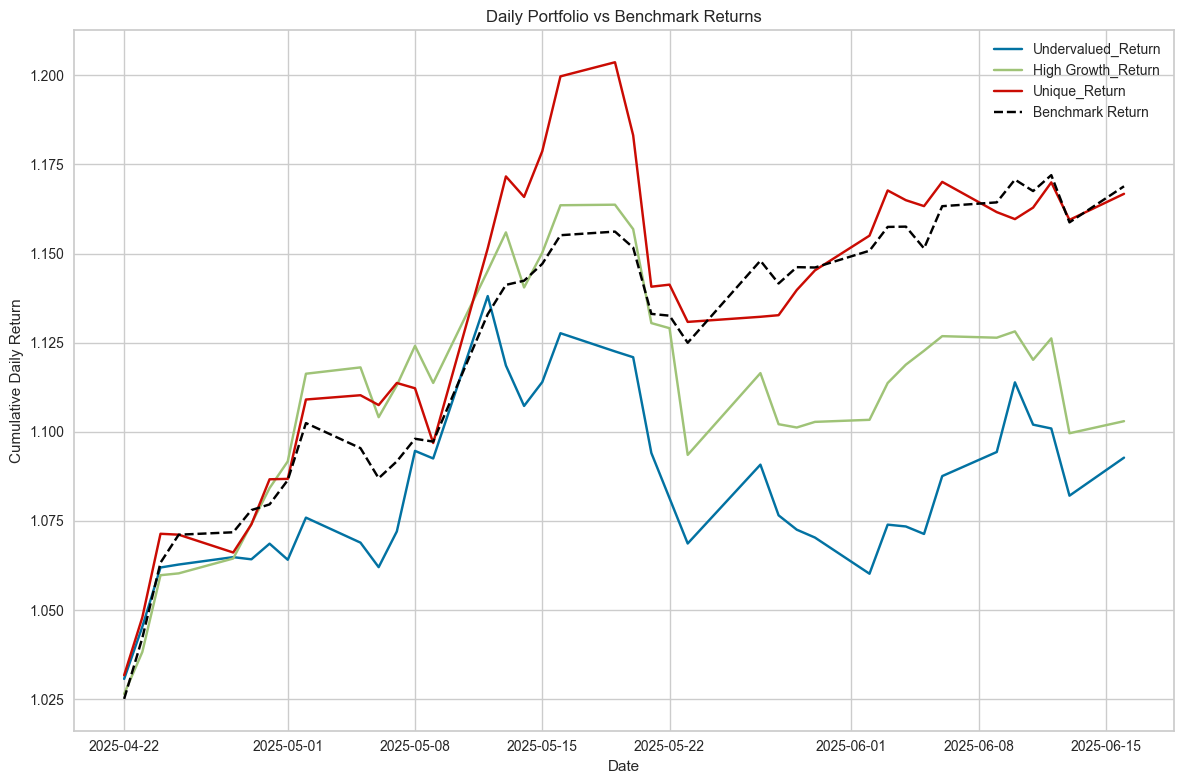

In [128]:
performance(port_data, cum_spx_ret, ['Undervalued','High Growth', 'Unique'])